In [1]:
#1.1.a) derive swbgt

from pathlib import Path
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import xesmf

import pandas as pd
import re
import glob
import warnings
import os


import dask #parralelle processing 
import subprocess
import dask.array as da
from memory_profiler import profile
from filelock import FileLock
from dask.diagnostics import ProgressBar

 
from dask.distributed import Client
client = Client()  # Or pass cluster details
client

warnings.filterwarnings("ignore", category=UserWarning) #mute warnings 

# ========== 1. File Finder ========== #
def find_input_files(var, period):
    base_path = "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
   
    path_mask = f"{var}_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_{period}*_regridded.nc"
    return sorted(glob.glob(os.path.join(base_path, path_mask)))

# ========== 2. Simplified WBGT Function ========== #
def compute_wbgt(tas, hurs):
    """
    Compute simplified WBGT using tas (K) and hurs (%).
    Returns DataArray with WBGT values (degC).
    """
    T_c = tas - 273.15
    e_s = 6.112 * np.exp((17.67 * T_c) / (T_c + 243.5))
    e = hurs * e_s / 100.0
    wbgt = 0.567 * T_c + 0.393 * e + 3.94


    return wbgt.assign_attrs({
        "long_name": "Simplified Wet-Bulb Globe Temperature",
        "units": "degC",
        "description": "W = 0.567T + 0.393e + 3.94 (Willett & Sherwood 2010)"
    }).rename("wbgt")

# ========== 3. Processing + Save Function ========== #
def process_and_save_wbgt(tas_files, hurs_files, outfile, chunk_time='auto'):
    """
    Compute simplified WBGT from tas and hurs file lists, save to NetCDF.
    """
    # Load with chunking for Dask efficiency
    ds_tas = xr.open_mfdataset(tas_files, combine='by_coords', decode_times=True)
    ds_hurs = xr.open_mfdataset(hurs_files, combine='by_coords', decode_times=True)

    # Rechunk after loading to avoid Dask warning
    ds_tas = ds_tas.chunk({'time': chunk_time})
    ds_hurs = ds_hurs.chunk({'time': chunk_time})
    # Compute WBGT
    wbgt = compute_wbgt(ds_tas['tas'], ds_hurs['hurs'])

    # Create dataset and save with progress bar
    wbgt_ds = wbgt.to_dataset()

    # Drop 'crs' if it exists
    if 'crs' in wbgt_ds.coords:
        wbgt_ds = wbgt_ds.drop_vars('crs')
        
    print("Final variables:", list(wbgt_ds.data_vars))
    
    # with ProgressBar():
    #     wbgt_ds.to_netcdf(outfile, compute=True)
    def safe_write(ds, outfile):

        ds = ds.copy()
    
        # remove encoding corruption (CRITICAL)
        if "time" in ds.coords:
            ds["time"].encoding.clear()
    
        # force materialisation if dask
        if hasattr(ds, "compute"):
            ds = ds.compute()
    
        tmp = outfile + ".tmp.nc"
        
        if os.path.exists(tmp):
            os.remove(tmp)
    
        ds.to_netcdf(tmp, mode="w")
    
        os.replace(tmp, outfile)
    
        print("saved:", outfile)
        
    safe_write(wbgt_ds,outfile)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37875 instead
  warnings.warn(
2026-06-28 21:28:29,696 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4a7ea748016e239bf5043393cc25aec2 initialized by task ('rechunk-merge-rechunk-transfer-14deca52df8d156532da18251856f370', 0, 0, 0, 9, 0, 0) executed on worker tcp://127.0.0.1:46253
2026-06-28 21:30:01,999 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4a7ea748016e239bf5043393cc25aec2 deactivated due to stimulus 'task-finished-1782646201.9964404'
2026-06-28 21:30:37,180 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4a7ea748016e239bf5043393cc25aec2 initialized by task ('rechunk-merge-rechunk-transfer-14deca52df8d156532da18251856f370', 0, 0, 0, 12, 0, 0) executed on worker tcp://127.0.0.1:33371
2026-06-28 21:30:45,842 - distri

In [ ]:
#1.2.a) execute 1.1 -wbgt

output_dir = "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
os.makedirs(output_dir, exist_ok=True)

import re  # 👈 For extracting period from filenames

                            
# Find all tas files for this config
tas_files = find_input_files('tas', period="")  # Empty period to get all

if not tas_files:
    print("⚠️ No tas files found — skipping.")
    

for tas_file in tas_files:
    # Extract period from filename
    match = re.search(r'_day_(\d{6}-\d{6})', tas_file)
    if not match:
        print(f"⚠️ period not found in {tas_file} — skipping.")
        continue

    period = match.group(1)

    # Find matching hurs file
    hurs_files = find_input_files('hurs', period)

    if not hurs_files:
        print(f"⚠️ No hurs file found for period {period} — skipping.")
        continue

    # Output filename
    outfile = (
        f"{output_dir}wbgt_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_{period}_regridded.nc"
    )
    # out_file = output_dir / tas_file.name.replace("hurs", "wbgt")

    try:
        process_and_save_wbgt([tas_file], hurs_files, outfile)
        print(f"✅ Saved: {outfile}")
    except Exception as e:
        print(f"❌ Failed: {outfile}\nError: {e}")



In [ ]:
#1.1.b) derive vp

from pathlib import Path
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import xesmf

import pandas as pd
import re
import glob
import warnings
import os


import dask #parralelle processing 
import subprocess
import dask.array as da
from memory_profiler import profile
from filelock import FileLock
from dask.diagnostics import ProgressBar

 
from dask.distributed import Client
client = Client()  # Or pass cluster details
client

warnings.filterwarnings("ignore", category=UserWarning) #mute warnings 

# ========== 1. File Finder ========== #
def find_input_files(var, period):
    base_path = "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
   
    path_mask = f"{var}_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_{period}*_regridded.nc"
    return sorted(glob.glob(os.path.join(base_path, path_mask)))

# ========== 2. Simplified vp Function ========== #
def compute_vp(tas, hurs):
    """
    Compute vp using tas (K) and hurs (%).
    Returns DataArray with vp values (hPa).
    """
    T_c = tas - 273.15
    e_s = 6.112 * np.exp((17.67 * T_c) / (T_c + 243.5))
    # e = hurs * e_s / 100.0
    vp = hurs * e_s / 100.0
    # wbgt = 0.567 * T_c + 0.393 * e + 3.94


    return vp.assign_attrs({
        "long_name": "Water Vapour Pressure",
        "units": "hPa",
        "description": "Calculated from air temperature and relative humidity using the August-Roche-Magnus approximation of Magnus equation"
    }).rename("vp")

# ========== 3. Processing + Save Function ========== #
def process_and_save_vp(tas_files, hurs_files, outfile, chunk_time='auto'):
    """
    Compute vp from tas and hurs file lists, save to NetCDF.
    """
    # Load with chunking for Dask efficiency
    ds_tas = xr.open_mfdataset(tas_files, combine='by_coords', decode_times=True)
    ds_hurs = xr.open_mfdataset(hurs_files, combine='by_coords', decode_times=True)

    # Rechunk after loading to avoid Dask warning
    ds_tas = ds_tas.chunk({'time': chunk_time})
    ds_hurs = ds_hurs.chunk({'time': chunk_time})
    # Compute vp
    vp = compute_vp(ds_tas['tas'], ds_hurs['hurs'])

    # Create dataset and save with progress bar
    vp_ds = vp.to_dataset()

    # Drop 'crs' if it exists
    if 'crs' in vp_ds.coords:
        vp_ds = vp_ds.drop_vars('crs')
        
    print("Final variables:", list(vp_ds.data_vars))
    
    # with ProgressBar():
    #     vp_ds.to_netcdf(outfile, compute=True)
    def safe_write(ds, outfile):

        ds = ds.copy()
    
        # remove encoding corruption (CRITICAL)
        if "time" in ds.coords:
            ds["time"].encoding.clear()
    
        # force materialisation if dask
        if hasattr(ds, "compute"):
            ds = ds.compute()
    
        tmp = outfile + ".tmp.nc"
        
        if os.path.exists(tmp):
            os.remove(tmp)
    
        ds.to_netcdf(tmp, mode="w")
    
        os.replace(tmp, outfile)
    
        print("saved:", outfile)
        
    safe_write(vp_ds,outfile)

In [ ]:
#1.2.b) execute 1.1 --vp

output_dir = "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
os.makedirs(output_dir, exist_ok=True)

import re  # 👈 For extracting period from filenames

                            
# Find all tas files for this config
tas_files = find_input_files('tas', period="")  # Empty period to get all

if not tas_files:
    print("⚠️ No tas files found — skipping.")
    

for tas_file in tas_files:
    # Extract period from filename
    match = re.search(r'_day_(\d{6}-\d{6})', tas_file)
    if not match:
        print(f"⚠️ period not found in {tas_file} — skipping.")
        continue

    period = match.group(1)

    # Find matching hurs file
    hurs_files = find_input_files('hurs', period)

    if not hurs_files:
        print(f"⚠️ No hurs file found for period {period} — skipping.")
        continue

    # Output filename
    outfile = (
        f"{output_dir}vp_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_{period}_regridded.nc"
    )
    

    try:
        process_and_save_vp([tas_file], hurs_files, outfile)
        print(f"✅ Saved: {outfile}")
    except Exception as e:
        print(f"❌ Failed: {outfile}\nError: {e}")



In [3]:

#2. BARRA2 calculate exceedance over 1979-2025 instead of 1979-2014, using 1979-2014 baseline
#calculate 99th percentile historical baseline, exceedance , and summarise annual exceedance count by NRM 
import xarray as xr
import dask
from filelock import FileLock
import glob 

#BARRA2 pattern 

def load_dataset(data_dir, variable):
    path_mask = (
        f"{data_dir}/{variable}_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_*_regridded.nc"
    )
    print("data_dir =", data_dir)
    print("pattern =", path_mask)
    files = glob.glob(path_mask)

    # def sanitize(ds):
    #     return ds.drop_dims('crs')
    def sanitize(ds):
        if "crs" in ds.dims:
            ds = ds.drop_dims("crs")
        if "crs" in ds.variables:
            ds = ds.drop_vars("crs")
        return ds

    with dask.config.set(**{'array.slicing.split_large_chunks': False}):
        ds = xr.open_mfdataset(files, preprocess=sanitize, combine='by_coords')
    
    return ds.chunk(chunks={'time': -1, 'lat': 'auto', 'lon': 'auto'})



# ============================================================
# CALCULATE THRESHOLD + EXCEEDANCE
# ============================================================

def determine_univariate(
    data,
    out_prefix,
    thresh=0.99,
    ttype='q+',
    baseline_start="1979-01-01",
    baseline_end="2014-12-31",
    period_start="1979-01-01",
    period_end="2025-12-31",
):

    # ========================================================
    # SELECT BASELINE PERIOD
    # ========================================================
    
    data_sel=data.sel(
        time=slice(
            period_start,
            period_end
        )
    )
    
    baseline_data = data.sel(
        time=slice(
            baseline_start,
            baseline_end
        )
    )

    # ========================================================
    # COMPUTE THRESHOLD
    # ========================================================

    if 'q' in ttype:

        threshold = baseline_data.quantile(
            thresh,
            dim='time',
            skipna=True
        )

    else:

        threshold = xr.full_like(
            baseline_data.isel(time=0),
            thresh
        )

    # ========================================================
    # CALCULATE EXCEEDANCE
    # ONLY FOR 1979-2014
    # ========================================================

    if '+' in ttype:

        univ_exceed = xr.where(
            data_sel > threshold,
            1,
            0
        )

    else:

        univ_exceed = xr.where(
            data_sel < threshold,
            1,
            0
        )

    # ========================================================
    # OUTPUT FILES (NO HARDCODED YEARS)
    # ========================================================
    
    suffix = f"{period_start[:4]}_{period_end[:4]}"
    
    out_file = f"{out_prefix}_univ_exceed_{suffix}.nc"
    threshold_out_file = f"{out_prefix}_threshold_{suffix}.nc"

    # ========================================================
    # REMOVE OLD FILES
    # avoids PermissionError from append mode
    # ========================================================

    import os

    for f in [out_file, threshold_out_file]:

        if os.path.exists(f):

            os.remove(f)

    # ========================================================
    # SAVE EXCEEDANCE
    # ========================================================

    with FileLock(f"{out_file}.lock"):

        univ_exceed.to_netcdf(
            out_file,
            mode="w"
        )

    # ========================================================
    # SAVE THRESHOLD
    # ========================================================

    with FileLock(f"{threshold_out_file}.lock"):

        threshold.to_netcdf(
            threshold_out_file,
            mode="w"
        )

    print(f"Saved exceedance:\n{out_file}")

    print(f"Saved threshold:\n{threshold_out_file}")

In [2]:
#2.1.longer period . extract univ exceed for tas (same as 5 but for wbgt)
variable = 'tas'   
data_dir = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/'
out_dir = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/'

ds = load_dataset(data_dir, variable)

data = ds[variable]
import inspect
determine_univariate(
    data=data,
    out_prefix="/scratch/dt6/xw9650/tmp/regridded_BARRA2/tas",
    thresh=0.99,
    ttype="q+",
    baseline_start="1979-01-01",
    baseline_end="2014-12-31",
    period_start="1979-01-01",
    period_end="2025-12-31",
)

data_dir = /scratch/dt6/xw9650/tmp/regridded_BARRA2/
pattern = /scratch/dt6/xw9650/tmp/regridded_BARRA2//tas_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_*_regridded.nc
Saved exceedance:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/tas_univ_exceed_1979_2025.nc
Saved threshold:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/tas_threshold_1979_2025.nc


In [3]:
#2.2.longer period . extract univ exceed for tas (same as 5 but for wbgt)
variable = 'hurs'   
data_dir = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/'
out_dir = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/'

ds = load_dataset(data_dir, variable)

data = ds[variable]
import inspect
determine_univariate(
    data=data,
    out_prefix="/scratch/dt6/xw9650/tmp/regridded_BARRA2/hurs",
    thresh=0.99,
    ttype="q+",
    baseline_start="1979-01-01",
    baseline_end="2014-12-31",
    period_start="1979-01-01",
    period_end="2025-12-31",
)

data_dir = /scratch/dt6/xw9650/tmp/regridded_BARRA2/
pattern = /scratch/dt6/xw9650/tmp/regridded_BARRA2//hurs_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_*_regridded.nc
Saved exceedance:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/hurs_univ_exceed_1979_2025.nc
Saved threshold:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/hurs_threshold_1979_2025.nc


In [4]:
#2.3.a)longer period . extract univ exceed for tas (same as 5 but for wbgt)
variable = 'wbgt'   
data_dir = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/'
out_dir = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/'

ds = load_dataset(data_dir, variable)

data = ds[variable]
import inspect
determine_univariate(
    data=data,
    out_prefix="/scratch/dt6/xw9650/tmp/regridded_BARRA2/wbgt",
    thresh=0.99,
    ttype="q+",
    baseline_start="1979-01-01",
    baseline_end="2014-12-31",
    period_start="1979-01-01",
    period_end="2025-12-31",
)

data_dir = /scratch/dt6/xw9650/tmp/regridded_BARRA2/
pattern = /scratch/dt6/xw9650/tmp/regridded_BARRA2//wbgt_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_*_regridded.nc
Saved exceedance:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/wbgt_univ_exceed_1979_2025.nc
Saved threshold:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/wbgt_threshold_1979_2025.nc


In [4]:
#2.4.longer period . extract univ exceed for tas (same as 5 but for vp)
variable = 'vp'   
data_dir = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/'
out_dir = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/'

ds = load_dataset(data_dir, variable)

data = ds[variable]
import inspect
determine_univariate(
    data=data,
    out_prefix="/scratch/dt6/xw9650/tmp/regridded_BARRA2/vp",
    thresh=0.99,
    ttype="q+",
    baseline_start="1979-01-01",
    baseline_end="2014-12-31",
    period_start="1979-01-01",
    period_end="2025-12-31",
)

data_dir = /scratch/dt6/xw9650/tmp/regridded_BARRA2/
pattern = /scratch/dt6/xw9650/tmp/regridded_BARRA2//vp_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_*_regridded.nc
Saved exceedance:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/vp_univ_exceed_1979_2025.nc
Saved threshold:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/vp_threshold_1979_2025.nc


In [1]:
#3. 
#calculate NARCliM2.0 univ_exceed for 1979-2025 using 1979-2014 baseline 

#00. libraries and dask client 
import time
import xarray as xr
import numpy as np
import pandas as pd
import glob
import datetime
import time
import os
import gc

import matplotlib
import xarray, matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import cartopy
import cartopy.crs as ccrs
# import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm



import dask #parralelle processing 
import subprocess
import dask.array as da
from memory_profiler import profile
from filelock import FileLock
from dask.distributed import Client
from dask.utils import SerializableLock


from dask.diagnostics import ProgressBar

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34135,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35095,Total threads: 2
Dashboard: /proxy/35117/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:45795,


2026-08-30 15:25:10,403 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle f3ce8cd18fcde048e61a49f6e3b2fb5d initialized by task ('rechunk-merge-rechunk-transfer-df6a0ebd3e1fb4e1328a713bb134a721', 0, 0, 0, 8, 0, 0) executed on worker tcp://127.0.0.1:39971
2026-08-30 15:25:12,719 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e642a771251b24a96efe86341d8d3cfa initialized by task ('rechunk-merge-rechunk-transfer-6e76f8e15a925ea724699367c2dd65e5', 0, 0, 0, 9, 0, 0) executed on worker tcp://127.0.0.1:35169
2026-08-30 15:25:15,363 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle f3ce8cd18fcde048e61a49f6e3b2fb5d deactivated due to stimulus 'task-finished-1788067515.3624792'
2026-08-30 15:25:17,000 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e642a771251b24a96efe86341d8d3cfa deactivated due to stimulus 'task-finished-1788067516.989076'
2026-08-30 15:29:19,436 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e642a771251b24a96efe86341d8d3

In [2]:
#5.0-2.0 define functions (modified version to deal with UKESM and NorESM data dimensions)

def load_dataset(
    var,
    domain,
    GCM,
    scenario,
    meG,
    provider,
    RCM,
    meR,
    tempRes,
    idir
):

    path_mask = (
        f"{IDIR}{var}_{domain}_{GCM}_{sc}_{meG}_"
        f"{provider}_{RCM}_{meR}_{tempRes}_*.nc"
    )

    files = glob.glob(path_mask)

    # --------------------------------------------------------
    # remove problematic CRS variables
    # --------------------------------------------------------

    def sanitize(ds):

        if "crs" in ds.dims:
            ds = ds.drop_dims("crs")

        if "crs" in ds.variables:
            ds = ds.drop_vars("crs")

        return ds

    # --------------------------------------------------------
    # open dataset
    # --------------------------------------------------------

    with dask.config.set(
        **{'array.slicing.split_large_chunks': False}
    ):

        ds = xr.open_mfdataset(
            files,
            preprocess=sanitize,
            combine='by_coords',
            chunks={'time': -1}
        )

    # --------------------------------------------------------
    # chunk ONLY data variables
    # --------------------------------------------------------

    for v in ds.data_vars:

        if {'time', 'lat', 'lon'}.issubset(ds[v].dims):

            ds[v] = ds[v].chunk({
                'time': -1,
                'lat': 'auto',
                'lon': 'auto'
            })

    return ds


def determine_univariate(
    data,
    out_prefix,
    thresh=0.99,
    ttype='q+',
    baseline_start='1979-01-01',
    baseline_end='2014-12-31', 
    period_start='1979-01-01',
    period_end='2025-12-31',
):

    import os

    # --------------------------------------------------------
    # select baseline period
    # --------------------------------------------------------

    # --------------------------------------------------------
    # select baseline years
    # works for 360_day / 365_day / standard calendars
    # --------------------------------------------------------
    
    baseline_start_year = int(baseline_start[:4])
    baseline_end_year = int(baseline_end[:4])
    
    data_baseline = data.where(
        (data.time.dt.year >= baseline_start_year) &
        (data.time.dt.year <= baseline_end_year),
        drop=True
    )

    period_start_year = int(period_start[:4])
    period_end_year = int(period_end[:4])
    
    data_sel = data.where(
        (data.time.dt.year >= period_start_year) &
        (data.time.dt.year <= period_end_year),
        drop=True
    )
    
    # --------------------------------------------------------
    # threshold from 1979-2014 only
    # --------------------------------------------------------

    if 'q' in ttype:

        threshold = data_baseline.quantile(
            thresh,
            dim='time',
            skipna=True
        )

    else:

        threshold = thresh

    # --------------------------------------------------------
    # exceedance ONLY for 1979-2014
    # --------------------------------------------------------

    if '+' in ttype:

        univ_exceed = xr.where(
            data_sel > threshold,
            1,
            0
        )

    else:

        univ_exceed = xr.where(
            data_sel < threshold,
            1,
            0
        )


    # ========================================================
    # OUTPUT FILES (NO HARDCODED YEARS)
    # ========================================================
    
    suffix = f"{period_start[:4]}_{period_end[:4]}"
    
    out_file = f"{out_prefix}_univ_exceed_{suffix}.nc"
    threshold_out_file = f"{out_prefix}_threshold_{suffix}.nc"
    # --------------------------------------------------------
    # remove existing files
    # --------------------------------------------------------

    for f in [out_file, threshold_out_file]:

        if os.path.exists(f):

            os.remove(f)

    # --------------------------------------------------------
    # save exceedance
    # --------------------------------------------------------

    with FileLock(f"{out_file}.lock"):

        univ_exceed.to_netcdf(
            out_file,
            mode='w'
        )

    # --------------------------------------------------------
    # save threshold
    # --------------------------------------------------------

    with FileLock(f"{threshold_out_file}.lock"):

        threshold.to_netcdf(
            threshold_out_file,
            mode='w'
        )

    print(f"Saved:\n{out_file}")

    print(f"Saved:\n{threshold_out_file}")



In [3]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['ACCESS-ESM1-5']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['wbgt']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r6i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc


In [19]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['ACCESS-ESM1-5']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['hurs','tas']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r6i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BA

In [3]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['ACCESS-ESM1-5']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3','NARCliM2-0-WRF412R5'] 
vars = ['vp']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r6i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc


In [4]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['EC-Earth3-Veg']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['wbgt']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_EC-Earth3-Veg_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_EC-Earth3-Veg_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc


In [20]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['EC-Earth3-Veg']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['hurs','tas']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_EC-Earth3-Veg_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_EC-Earth3-Veg_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BA

In [4]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['EC-Earth3-Veg']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['vp']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_EC-Earth3-Veg_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_EC-Earth3-Veg_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_EC-Earth3-Veg_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc


In [7]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['MPI-ESM1-2-HR']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['wbgt']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc


In [21]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['MPI-ESM1-2-HR']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['tas','hurs']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BAR

In [5]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['MPI-ESM1-2-HR']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['vp']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc


In [ ]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['NorESM2-MM']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['wbgt']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc


In [22]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['NorESM2-MM']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['tas','hurs']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_NorESM2-MM_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_NorESM2-MM_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_NorESM2-MM_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCli

In [6]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['NorESM2-MM']  # Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['vp']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f1'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_NorESM2-MM_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_NorESM2-MM_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_NorESM2-MM_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc


In [2]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['UKESM1-0-LL']# Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['wbgt']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f2'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

TypeError: load_dataset() takes 2 positional arguments but 10 were given

In [23]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['UKESM1-0-LL']# Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['tas','hurs']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f2'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/regridded/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_UKESM1-0-LL_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_UKESM1-0-LL_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_UKESM1-0-LL_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/tas_UKESM1-0-LL_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_UKESM1-0-LL_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_UKESM1-0-LL_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc


HDF5-DIAG: Error detected in HDF5 (1.14.3) thread 0:
  #000: H5F.c line 836 in H5Fopen(): unable to synchronously open file
    major: File accessibility
    minor: Unable to open file
  #001: H5F.c line 796 in H5F__open_api_common(): unable to open file
    major: File accessibility
    minor: Unable to open file
  #002: H5VLcallback.c line 3863 in H5VL_file_open(): open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLcallback.c line 3675 in H5VL__file_open(): open failed
    major: Virtual Object Layer
    minor: Can't open object
  #004: H5VLnative_file.c line 128 in H5VL__native_file_open(): unable to open file
    major: File accessibility
    minor: Unable to open file
  #005: H5Fint.c line 1910 in H5F_open(): unable to lock the file
    major: File accessibility
    minor: Unable to lock file
  #006: H5FD.c line 2412 in H5FD_lock(): driver lock request failed
    major: Virtual File Layer
    minor: Unable to lock file
  #007: H5FDsec2.c line 941 

OSError: [Errno -101] NetCDF: HDF error: '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/hurs_UKESM1-0-LL_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc'

In [7]:
#5.0-2.1 iteration --ACCESS 
GCMs = ['UKESM1-0-LL']# Add more GCMs here
RCMs = ['NARCliM2-0-WRF412R3', 'NARCliM2-0-WRF412R5']
vars = ['vp']

scenarios = ['historical', 'ssp370']


for var in vars:
    for GCM in GCMs:
        for RCM in RCMs:
            meG = 'r1i1p1f2'
            meR = 'v1-r1'
            domain = 'AUS-18'
            provider = 'NSW-Government'
            tempRes = 'day'
            IDIR = '/scratch/dt6/xw9650/tmp/derived/'
            OUTDIR = '/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/'
            
            # Load both scenarios
            datasets = []
            for sc in scenarios:
                ds = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)
                datasets.append(ds)

            # Combine historical and future
            data = xr.concat(datasets, dim='time').sortby('time')
   
            # data = load_dataset(var, domain, GCM, sc, meG, provider, RCM, meR, tempRes, IDIR)

            prefix = f"{OUTDIR}{var}_{GCM}_{RCM}_{sc}"
                
            #this is modified to accommodate 1979-2015 -combining historical and future 
            determine_univariate(data[var], prefix, thresh=0.99, ttype='q+', baseline_start='1979-01-01',baseline_end='2014-12-31', period_start='1979-01-01',period_end='2025-12-31')
    

Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_UKESM1-0-LL_NARCliM2-0-WRF412R3_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_UKESM1-0-LL_NARCliM2-0-WRF412R3_ssp370_threshold_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_UKESM1-0-LL_NARCliM2-0-WRF412R5_ssp370_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/vp_UKESM1-0-LL_NARCliM2-0-WRF412R5_ssp370_threshold_1979_2025.nc


In [10]:
# redesign 5.1--wbgt
# ============================================================
# COMPUTE ANNUAL HURS EXCEEDANCE SUMMARIES
# DASK-OPTIMISED VERSION
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

barra2_file = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
    "wbgt_univ_exceed_1979_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/"
    "wbgt_{gcm}_{rcm}_ssp370_univ_exceed_1979_2025.nc"
)

mask_shapefile = (
    "/scratch/dt6/xw9650/tmp/reference_data/"
    "NRM_clusters/NRM_clusters.shp"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2"
)

summary_dir = output_dir / "summaries"

output_dir.mkdir(exist_ok=True)

summary_dir.mkdir(exist_ok=True)

mask_nc = output_dir / "nrm_mask.nc"

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# CREATE REGION MASK ONCE
# ============================================================

def create_nrm_mask(
    sample_file,
    shapefile,
    out_file
):

    print("Creating NRM mask...")

    ds = xr.open_dataset(sample_file)

    gdf = (
        gpd.read_file(shapefile)
        .to_crs("EPSG:4326")
    )

    gdf = gdf[
        gdf.geometry.notnull()
    ]

    regions = regionmask.Regions(
        outlines=list(gdf.geometry),
        names=gdf["label"].tolist(),
        numbers=list(range(len(gdf)))
    )

    mask = regions.mask(
        ds.lon,
        ds.lat
    )

    mask.name = "nrm_mask"

    mask.to_netcdf(out_file)

    print(f"Saved mask:\n{out_file}")

# ============================================================
# CREATE MASK IF MISSING
# ============================================================

if not mask_nc.exists():

    create_nrm_mask(
        barra2_file,
        mask_shapefile,
        mask_nc
    )

# ============================================================
# LOAD MASK
# ============================================================

mask = xr.open_dataarray(mask_nc)

# ============================================================
# REGION NAMES
# ============================================================

gdf_regions = (
    gpd.read_file(mask_shapefile)
    .to_crs("EPSG:4326")
)

region_names = {
    i: name
    for i, name in enumerate(
        gdf_regions["label"].tolist()
    )
}

# ============================================================
# SUMMARY FUNCTION
# ============================================================

def summarise_annual_exceedance(
    nc_file,
    out_file,
    source_name
):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"time": 365}
    )

    # ========================================================
    # AUTO-DETECT VARIABLE
    # ========================================================

    var_name = list(ds.data_vars)[0]

    da = ds[var_name]

    # ========================================================
    # CONVERT BOOLEAN TO INTEGER
    # ========================================================

    if da.dtype == bool:

        da = da.astype("int16")

    # ========================================================
    # ANNUAL SUM
    # ========================================================

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # ========================================================
    # REGION IDS
    # ========================================================

    region_ids = np.unique(
        mask.values[
            np.isfinite(mask.values)
        ]
    ).astype(int)

    all_rows = []

    # ========================================================
    # LOOP REGIONS
    # ========================================================

    for region_id in region_ids:

        regional = (
            annual
            .where(mask == region_id)
            .mean(dim=["lat", "lon"])
        )

        regional = regional.compute()

        years = regional["time.year"].values

        values = regional.values

        rows = pd.DataFrame({
            "NRM": region_names[region_id],
            "year": years.astype(int),
            "annual_exceedance_days": values.astype(float),
            "Source": source_name
        })

        all_rows.append(rows)

    # ========================================================
    # CONCATENATE
    # ========================================================

    df = pd.concat(
        all_rows,
        ignore_index=True
    )

    # ========================================================
    # SAVE
    # ========================================================

    df.to_parquet(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# CREATE TASKS
# ============================================================

tasks = []

# ============================================================
# BARRA2 TASK
# ============================================================

barra2_out = (
    summary_dir /
    "wbgt_BARRA2_summary_1979_2025.parquet"
)

tasks.append(
    delayed(
        summarise_annual_exceedance
    )(
        barra2_file,
        barra2_out,
        "BARRA2"
    )
)

# ============================================================
# MODEL TASKS
# ============================================================

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():

        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        summary_dir /
        f"wbgt_{gcm}_{rcm}_summary_1979_2025.parquet"
    )

    source_name = f"{gcm}_{rcm}"

    tasks.append(
        delayed(
            summarise_annual_exceedance
        )(
            model_file,
            out_file,
            source_name
        )
    )

# ============================================================
# RUN TASKS
# ============================================================

results = compute(*tasks)

print("\nFinished summaries:")

for r in results:
    print(r)

# ============================================================
# CLOSE CLIENT
# ============================================================

client.close()

<Client: 'tcp://127.0.0.1:33269' processes=8 threads=8, memory=59.60 GiB>

Finished summaries:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/wbgt_BARRA2_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/wbgt_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/wbgt_EC-Earth3-Veg_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/wbgt_EC-Earth3-Veg_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/wbgt_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/wbgt_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/wbgt_NorESM2-MM_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratc

In [13]:
# redesign 5.2 -create gridcell trends data --wbgt
# redesign 5.2 -create gridcell trends data 
# ============================================================
# COMPUTE GRIDCELL TRENDS FROM EXCEEDANCE DATA
# VECTORISED + DASK OPTIMISED
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import xarray as xr
from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

START_YEAR = 1979
END_YEAR = 2025

obs_file = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
    "wbgt_univ_exceed_1979_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/"
    "wbgt_{gcm}_{rcm}_ssp370_univ_exceed_1979_2025.nc"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# TREND FUNCTION
# ============================================================

def compute_gridcell_trend(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    # --------------------------------------------------------
    # OPEN
    # --------------------------------------------------------

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # ============================================================
    # FILTER TIME (CRITICAL FIX)
    # ============================================================

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    # --------------------------------------------------------
    # BOOLEAN -> INTEGER
    # --------------------------------------------------------

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL EXCEEDANCE DAYS
    # --------------------------------------------------------

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # --------------------------------------------------------
    # YEAR COORDINATE
    # --------------------------------------------------------

    annual = annual.assign_coords(
        year=("time", annual["time.year"].values)
    )

    # --------------------------------------------------------
    # TREND (PIXEL-WISE)
    # --------------------------------------------------------

    trend_ds = annual.polyfit(
        dim="year",
        deg=1,
        skipna=True
    )

    slope = trend_ds.polyfit_coefficients.sel(degree=1)
    slope.name = "trend"

    slope.attrs["description"] = (
        f"Trend in annual exceedance days "
        f"(days/year), {START_YEAR}-{END_YEAR}"
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    slope.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file
# ============================================================
# TREND FUNCTION (UPDATED to include p-value)
# ============================================================

def compute_gridcell_trend_with_pvalue(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # --------------------------------------------------------
    # TIME FILTER
    # --------------------------------------------------------

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL SUM
    # --------------------------------------------------------

    annual = da.resample(time="YE").sum(dim="time")

    years = annual["time.year"].values

    # ========================================================
    # MINIMAL CHANGE: ADD SIGNIFICANCE VIA LINREGRESS
    # ========================================================

    def _trend(y):

        if np.all(np.isnan(y)):
            return np.array([np.nan, np.nan])

        slope, intercept, r, p, stderr = linregress(years, y)

        return np.array([slope, p])   # slope + p-value

    result = xr.apply_ufunc(
        _trend,
        annual,
        input_core_dims=[["time"]],
        output_core_dims=[["stat"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={"stat": 2}
    )

    slope = result.isel(stat=0)
    pval = result.isel(stat=1)

    slope.name = "trend"
    pval.name = "p_value"

    slope.attrs["description"] = (
        f"Trend in annual exceedance (days/year), "
        f"{START_YEAR}-{END_YEAR}"
    )

    pval.attrs["description"] = "p-value of linear trend"

    # --------------------------------------------------------
    # SAVE (NOW DATASET INSTEAD OF SINGLE VARIABLE)
    # --------------------------------------------------------

    out_ds = xr.Dataset({
        "trend": slope,
        "p_value": pval
    })

    out_ds.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# TASKS
# ============================================================

tasks = []

# ------------------------------------------------------------
# OBS
# ------------------------------------------------------------

obs_out = (
    output_dir /
    "wbgt_BARRA2_trend_1979_2025.nc"
)

tasks.append(
    delayed(compute_gridcell_trend_with_pvalue)(
        obs_file,
        obs_out
    )
)

# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():
        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        output_dir /
        f"wbgt_{gcm}_{rcm}_trend_1979_2025.nc"
    )

    tasks.append(
        delayed(compute_gridcell_trend)(
            model_file,
            out_file
        )
    )

# ============================================================
# RUN
# ============================================================

results = compute(*tasks)

print("\nFinished trend calculations:")
print(results)

<Client: 'tcp://127.0.0.1:42173' processes=8 threads=8, memory=59.60 GiB>


/jobfs/172674658.gadi-pbs/ipykernel_1657046/1930284677.py:199: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.



Finished trend calculations:
(PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/wbgt_BARRA2_trend_1979_2025.nc'),)


In [ ]:
#5.2.2 +add sign agreement --wbgt
# ============================================================
# MULTI-MODEL MEDIAN TREND
# + SIGN AGREEMENT
# ============================================================

import xarray as xr
import numpy as np

from pathlib import Path

# ============================================================
# PATHS
# ============================================================

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

# ============================================================
# LOAD ALL MODEL TREND FILES
# ============================================================

model_trends = []

model_names = []

for f in trend_dir.glob("wbgt*_trend_1979_2025.nc"):

    if "BARRA2" in f.name:
        continue

    if "MMM" in f.name:
        continue

    da = xr.open_dataarray(f)

    model_trends.append(da)

    model_names.append(f.stem)

print(f"Loaded {len(model_trends)} model trend files")

# ============================================================
# STACK MODELS
# ============================================================

stacked = xr.concat(
    model_trends,
    dim="model"
)

stacked["model"] = model_names

# ============================================================
# MULTI-MODEL MEDIAN
# ============================================================

mmm_trend = stacked.median(dim="model")

mmm_trend.name = "MMM_trend"

# ============================================================
# SIGN AGREEMENT
# ============================================================

# Positive trend models
n_positive = (stacked > 0).sum(dim="model")

# Negative trend models
n_negative = (stacked < 0).sum(dim="model")

# Total valid models
n_total = np.isfinite(stacked).sum(dim="model")

# Maximum agreement
max_agree = xr.ufuncs.maximum(
    n_positive,
    n_negative
)

# Fraction agreeing on sign
sign_agreement = (
    max_agree / n_total
)

sign_agreement.name = "sign_agreement"

sign_agreement.attrs = {
    "description":
        "Fraction of ensemble members agreeing on trend sign"
}

# ============================================================
# STIPPLE MASK
# ============================================================

stippling = sign_agreement >= 0.7

stippling.name = "stippling"

stippling.attrs = {
    "description":
        "True where >=70% of models agree on trend sign"
}

# ============================================================
# CREATE OUTPUT DATASET
# ============================================================

ds_out = xr.Dataset({

    "MMM_trend": mmm_trend,

    "sign_agreement": sign_agreement,

    "stippling": stippling

})

# ============================================================
# ATTRIBUTES
# ============================================================

ds_out["MMM_trend"].attrs = {
    "description":
        "Multimodel median trend (days/year)"
}

# ============================================================
# SAVE
# ============================================================

mmm_out = trend_dir / "wbgt_MMM_trend_1979_2025.nc"

ds_out.to_netcdf(mmm_out)

print(f"Saved multimodel median trend:\n{mmm_out}")

Detected NRMs:
['Central Slopes', 'East Coast', 'Monsoonal North', 'Murray Basin', 'Rangelands', 'Southern Slopes', 'Southern and South-Western Flatlands', 'Wet Tropics']
Saved trend table:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/wbgt_annual_exceedance_trends_1979_2025.csv


/jobfs/178930538.gadi-pbs/ipykernel_3448579/3720503408.py:923: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


Saved figure:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/wbgt_combined_timeseries_maps_1979_2025.png


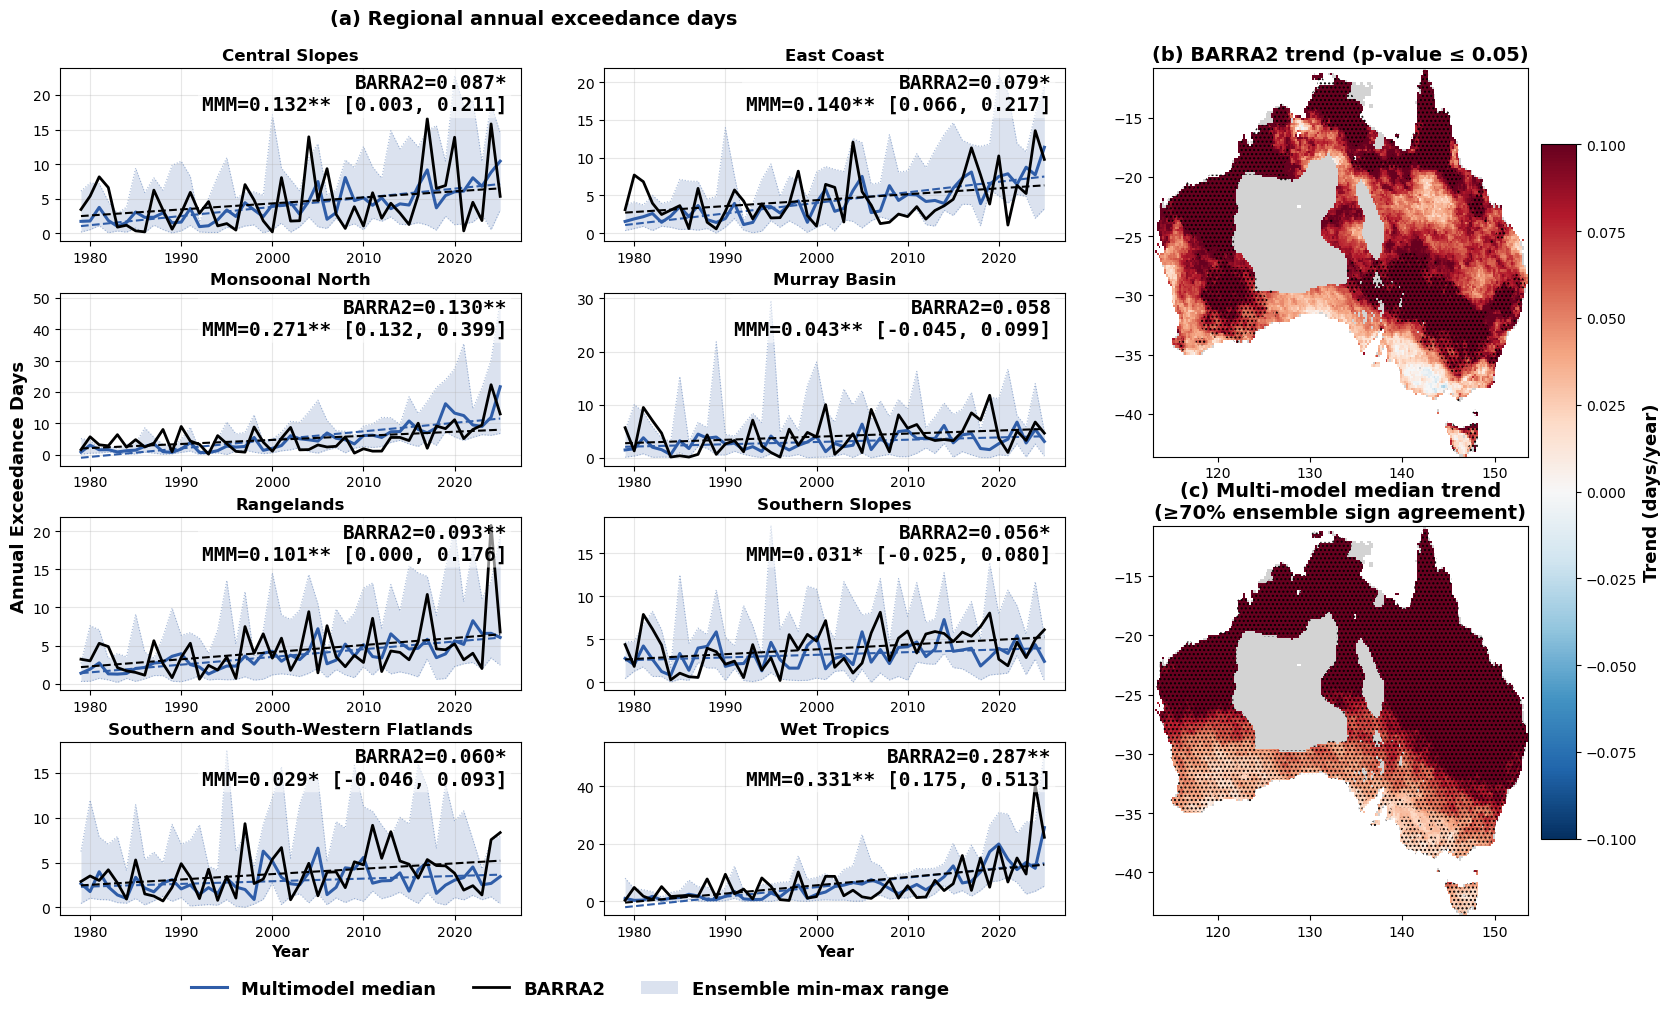

In [1]:
# ============================================================
# 5.5 COMBINED VISUALISATION -wbgt
# LEFT: NRM TIMESERIES (from redesign 5.2 style)
# RIGHT: BARRA2 + MMM TREND MAPS + exclude 
# 
# ============================================================

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.stats import linregress
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# SETTINGS
# ============================================================

summary_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries"
)

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2"
)

output_dir.mkdir(exist_ok=True)

# ============================================================
# MODELS
# ============================================================

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# LOAD LAND MASK
# ============================================================

mask_file = (
    "/scratch/dt6/xw9650/tmp/regridded/"
    "sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_"
    "NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"
)

land_mask = xr.open_dataset(mask_file)["sftlf"] > 50

# ============================================================
# Excluded region MASK
# ============================================================
mask_region = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/original_awra_awap_mask.nc')

def regrid_mask(mask, target_data):
 
    mask = mask.sortby('lat')
 
    max_lat = mask['lat'].max().values
    min_lat = mask['lat'].min().values
    max_lon = mask['lon'].max().values
    min_lon = mask['lon'].min().values
 
    mask = mask.astype(int)
 
    target_data = target_data.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    regridded_mask = mask.interp_like(target_data, method='nearest')
    new_access_mask = regridded_mask.astype(bool)
 
    return new_access_mask


# ============================================================
# TREND FUNCTION
# ============================================================

def compute_trend(years, values):

    mask = np.isfinite(values)

    years = years[mask]
    values = values[mask]

    if len(years) < 3:
        return np.nan, np.nan

    res = linregress(years, values)

    return res.slope, res.pvalue


# ============================================================
# SIGNIFICANCE STARS
# ============================================================

def stars(p):

    if np.isnan(p):
        return ""

    if p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# LOAD BARRA2 SUMMARY
# ============================================================

barra2_file = summary_dir / "wbgt_BARRA2_summary_1979_2025.parquet"

barra2_df = pd.read_parquet(barra2_file)

# ============================================================
# LOAD MODEL SUMMARIES
# ============================================================

ensemble_data = {}

for gcm, rcm in product(gcms, rcms):

    file = (
        summary_dir /
        f"wbgt_{gcm}_{rcm}_summary_1979_2025.parquet"
    )

    if not file.exists():

        print(f"Missing:\n{file}")
        continue

    ensemble_data[f"{gcm}_{rcm}"] = (
        pd.read_parquet(file)
    )

# ============================================================
# DETECT NRMS
# ============================================================

nrms = sorted(barra2_df["NRM"].unique())

print("Detected NRMs:")
print(nrms)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(20, 11)
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[2.2, 1],
    height_ratios=[1, 1],
    wspace=0.12,
    hspace=0.18
)

# ============================================================
# LEFT PANEL SUBGRID
# ============================================================

left_gs = gs[:, 0].subgridspec(
    4,
    2,
    wspace=0.18,
    hspace=0.30
)

axes = []

for i in range(len(nrms)):

    row = i // 2
    col = i % 2

    axes.append(
        fig.add_subplot(left_gs[row, col])
    )

# ============================================================
# RIGHT MAP PANELS
# ============================================================

ax_barra2 = fig.add_subplot(gs[0, 1])
ax_mmm = fig.add_subplot(gs[1, 1])

# ============================================================
# STORAGE
# ============================================================

trend_rows = []

# ============================================================
# MAIN LOOP
# ============================================================

for i, (ax, nrm) in enumerate(zip(axes, nrms)):

    ensemble_dfs = []

    # ========================================================
    # COLLECT ENSEMBLE MEMBERS
    # ========================================================

    for member_name, df in ensemble_data.items():

        df_nrm = df[
            df["NRM"] == nrm
        ][[
            "year",
            "annual_exceedance_days"
        ]].copy()

        if df_nrm.empty:
            continue

        df_nrm.rename(
            columns={
                "annual_exceedance_days": member_name
            },
            inplace=True
        )

        ensemble_dfs.append(
            df_nrm.set_index("year")
        )

    if not ensemble_dfs:
        continue

    # ========================================================
    # CREATE ENSEMBLE
    # ========================================================

    df_ensemble = pd.concat(
        ensemble_dfs,
        axis=1
    )

    years = df_ensemble.index.values

    # ========================================================
    # ENSEMBLE STATISTICS
    # ========================================================

    ensemble_median = (
        df_ensemble.median(axis=1)
    )

    ensemble_min = (
        df_ensemble.min(axis=1)
    )

    ensemble_max = (
        df_ensemble.max(axis=1)
    )

    # ========================================================
    # ENSEMBLE MIN-MAX SPREAD
    # ========================================================

    ax.fill_between(
        years,
        ensemble_min,
        ensemble_max,
        color="#4C72B0",
        alpha=0.20,
        linewidth=0,
        zorder=1
    )

    # OPTIONAL:
    # show min/max boundaries more clearly

    ax.plot(
        years,
        ensemble_min,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    ax.plot(
        years,
        ensemble_max,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    # ========================================================
    # MULTIMODEL MEDIAN
    # ========================================================

    ax.plot(
        years,
        ensemble_median,
        color="#2F5DA8",
        linewidth=2.2,
        label="Multimodel median",
        zorder=3
    )

    # ========================================================
    # MODEL TRENDS
    # ========================================================

    ensemble_slopes = []

    for col in df_ensemble.columns:

        slope_i, p_i = compute_trend(
            years,
            df_ensemble[col].values
        )

        ensemble_slopes.append(slope_i)

        trend_rows.append({
            "NRM": nrm,
            "Source": col,
            "Slope": slope_i,
            "p_value": p_i
        })

    mod_slope, mod_p = compute_trend(
        years,
        ensemble_median.values
    )

    ens_min = np.nanmin(ensemble_slopes)
    ens_max = np.nanmax(ensemble_slopes)

    trend_rows.append({
        "NRM": nrm,
        "Source": "Multimodel median",
        "Slope": mod_slope,
        "p_value": mod_p
    })

    # ========================================================
    # MULTIMODEL TREND LINE
    # ========================================================

    if np.isfinite(mod_slope):

        fit_mod = (
            mod_slope * years
            + np.mean(
                ensemble_median
                - mod_slope * years
            )
        )

        ax.plot(
            years,
            fit_mod,
            color="#2F5DA8",
            linestyle="--",
            linewidth=1.5,
            zorder=4
        )

    # ========================================================
    # BARRA2
    # ========================================================

    df_barra2 = barra2_df[
        barra2_df["NRM"] == nrm
    ]

    barra2_slope = np.nan
    barra2_p = np.nan

    if not df_barra2.empty:

        ax.plot(
            df_barra2["year"],
            df_barra2["annual_exceedance_days"],
            color="black",
            linewidth=2,
            label="BARRA2",
            zorder=5
        )

        x_barra2 = df_barra2["year"].values

        y_barra2 = df_barra2[
            "annual_exceedance_days"
        ].values

        barra2_slope, barra2_p = compute_trend(
            x_barra2,
            y_barra2
        )

        trend_rows.append({
            "NRM": nrm,
            "Source": "BARRA2",
            "Slope": barra2_slope,
            "p_value": barra2_p
        })

        if np.isfinite(barra2_slope):

            fit_barra2 = (
                barra2_slope * x_barra2
                + np.mean(
                    y_barra2
                    - barra2_slope * x_barra2
                )
            )

            ax.plot(
                x_barra2,
                fit_barra2,
                color="black",
                linestyle="--",
                linewidth=1.5,
                zorder=6
            )

    # ========================================================
    # PANEL TEXT
    # ========================================================

    text_str = (
        f"BARRA2={barra2_slope:.3f}{stars(barra2_p)}\n"
        f"MMM={mod_slope:.3f}{stars(mod_p)} "
        f"[{ens_min:.3f}, {ens_max:.3f}]"
    )

    # ax.text(
    #     0.97,
    #     0.97,
    #     text_str,
    #     transform=ax.transAxes,
    #     ha="right",
    #     va="top",
    #     fontsize=7.8,
    #     bbox=dict(
    #         facecolor="white",
    #         alpha=0.75,
    #         edgecolor="none",
    #         pad=1.5
    #     ),
    #     zorder=10
    # )
    ax.text(
        0.97,
        0.97,
        text_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight='bold',
        family="monospace",
        linespacing=1.2,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            alpha=0.55,
            edgecolor="none"
        ),
        zorder=10
    )
    # ========================================================
    # PANEL STYLE
    # ========================================================

    ax.set_title(
        nrm,
        fontsize=12,
        fontweight="bold"
    )

    row = i // 2

    if row == 3:

        ax.set_xlabel(
            "Year",
            fontsize=11,
            fontweight="bold"
        )

    else:

        ax.set_xlabel("")

    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FormatStrFormatter("%d")
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    ax.grid(
        alpha=0.3
    )

# ============================================================
# GLOBAL Y LABEL
# ============================================================

fig.text(
    0.1,
    0.5,
    "Annual Exceedance Days",
    va="center",
    rotation="vertical",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# LOAD TREND MAPS
# ============================================================

barra2_ds = xr.open_dataset(
    trend_dir / "wbgt_BARRA2_trend_1979_2025.nc"
)

mmm_ds = xr.open_dataset(
    trend_dir / "wbgt_MMM_trend_1979_2025.nc"
)

# ============================================================
# ALIGN MASK
# ============================================================

barra2_ds, land_mask_aligned = xr.align(
    barra2_ds,
    land_mask,
    join="inner"
)

mmm_ds, land_mask_aligned = xr.align(
    mmm_ds,
    land_mask,
    join="inner"
)

barra2_land = barra2_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
barra2_land_mask = regrid_mask(mask_region, barra2_land)
barra2_land_masked = barra2_land.where(barra2_land_mask)
    


mmm_land = mmm_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
mmm_land_mask = regrid_mask(mask_region, mmm_land)
mmm_land_masked = mmm_land.where(mmm_land_mask)
    
# ============================================================
# PLOT MAPS
# ============================================================

vmin = -0.1
vmax = 0.1

# ============================================================
# CREATE EXCLUDED LAND MASK
# ============================================================

# valid region mask after regridding
# True  = keep
# False = excluded

excluded_barra2 = (
    land_mask_aligned &
    (~barra2_land_mask)
)

excluded_mmm = (
    land_mask_aligned &
    (~mmm_land_mask)
)

# ============================================================
# LIGHT GRAY COLORMAP
# ============================================================

from matplotlib.colors import ListedColormap

gray_cmap = ListedColormap(["lightgray"])

# ============================================================
# PLOT EXCLUDED LAND FIRST
# ============================================================

xr.where(
    excluded_barra2,
    1,
    np.nan
).plot(
    ax=ax_barra2,
    cmap=gray_cmap,
    add_colorbar=False
)

xr.where(
    excluded_mmm,
    1,
    np.nan
).plot(
    ax=ax_mmm,
    cmap=gray_cmap,
    add_colorbar=False
)

# ============================================================
# OVERLAY ACTUAL TREND DATA
# ============================================================

barra2_plot = barra2_land_masked.trend.plot(
    ax=ax_barra2,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

# ============================================================
# BARRA2 SIGNIFICANCE STIPPLING (p <= 0.05)
# ============================================================

if "p_value" in barra2_land_masked:

    sig = barra2_land_masked["p_value"] <= 0.05

    step = 3  # adjust density (2–5 usually works well)

    sig_sparse = sig[::step, ::step]

    ax_barra2.contourf(
        barra2_land_masked.lon[::step],
        barra2_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
        # transform=barra2_plot.axes.get_transform("data")  # optional safety
    )
    

mmm_plot = mmm_land_masked.MMM_trend.plot(
    ax=ax_mmm,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
# ============================================================
# REMOVE AXIS LABELS (RIGHT PANELS)
# ============================================================

for ax in [ax_barra2, ax_mmm]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.tick_params(
    #     axis="both",
    #     which="both",
    #     length=3,      # removes tick marks
    #     labelbottom=False,
    #     labelleft=False
    # )
# # ============================================================
# # SIGN AGREEMENT STIPPLING
# # ============================================================

# if "sign_agreement" in mmm_land:

#     sig = mmm_land["sign_agreement"] >= 0.7

#     yy, xx = np.where(sig.values)

#     # reduced density for visibility

#     step = 10

#     yy = yy[::step]
#     xx = xx[::step]

#     ax_mmm.scatter(
#         mmm_land.lon.values[xx],
#         mmm_land.lat.values[yy],
#         s=0.7,
#         color="black",
#         alpha=0.28
#     )


# ============================================================
# HATCHING (70% AGREEMENT)
# ============================================================

if "sign_agreement" in mmm_land_masked:

    sig = mmm_land_masked["sign_agreement"] >= 0.7

    step = 2  # try 2, 3, 4, 5 depending on resolution

    sig_sparse = sig[::step, ::step]

    ax_mmm.contourf(
        mmm_land_masked.lon[::step],
        mmm_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
    )
    
# ============================================================
# MAP TITLES
# ============================================================

ax_barra2.set_title(
    "(b) BARRA2 trend (p-value ≤ 0.05)",
    fontsize=14,
    fontweight="bold"
)

ax_mmm.set_title(
    "(c) Multi-model median trend\n"
    "(≥70% ensemble sign agreement)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    barra2_plot,
    ax=[ax_barra2, ax_mmm],
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "Trend (days/year)",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# PANEL LABEL
# ============================================================

fig.text(
    0.26,
    0.92,
    "(a) Regional annual exceedance days",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# FIGURE LEGEND
# ============================================================

legend_handles = [

    plt.Line2D(
        [0], [0],
        color="#2F5DA8",
        linewidth=2.2
    ),

    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=2
    ),

    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor="#4C72B0",
        alpha=0.20
    )
]

# fig.legend(
#     legend_handles,
#     [
#         "Multimodel median",
#         "BARRA2",
#         "Ensemble min-max range"
#     ],
#     loc="lower center",
#     ncol=3,
#     fontsize=11,
#     frameon=False
# )
# ============================================================
# FIGURE LEGEND (LEFT PANEL ONLY)--CHANGE1
# ============================================================

# Get bounding box of left panel group
left_bbox = gs[:, 0].get_position(fig)

legend_handles = [

    plt.Line2D([0], [0], color="#2F5DA8", linewidth=2.2),
    plt.Line2D([0], [0], color="black", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, facecolor="#4C72B0", alpha=0.20)

]

legend=fig.legend(
    legend_handles,
    [
        "Multimodel median",
        "BARRA2",
        "Ensemble min-max range"
    ],
    loc="lower center",
    # bbox_to_anchor=(
    #     (left_bbox.x0 + left_bbox.x1) / 2,  # center x of LEFT panel
    #     left_bbox.y0 - 0.02                 # slightly below left panel
    # ),
    bbox_to_anchor=(0.38, 0.02),  # 👈 move into left panel bottom
    ncol=3,
    fontsize=13, #increase font size (CHANGE3),
    frameon=False
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# ============================================================
# SAVE TREND TABLE
# ============================================================

trend_df = pd.DataFrame(trend_rows)

trend_df["Slope"] = (
    trend_df["Slope"]
    .astype(float)
    .round(4)
)

trend_df["p_value"] = (
    trend_df["p_value"]
    .astype(float)
    .round(4)
)

trend_df["Slope_sig"] = (
    trend_df["Slope"].astype(str)
    + trend_df["p_value"].apply(stars)
)

trend_csv = (
    output_dir /
    "wbgt_annual_exceedance_trends_1979_2025.csv"
)

trend_xlsx = (
    output_dir /
    "wbgt_annual_exceedance_trends_1979_2025.xlsx"
)

trend_df.to_csv(
    trend_csv,
    index=False
)

trend_df.to_excel(
    trend_xlsx,
    index=False
)

print(f"Saved trend table:\n{trend_csv}")

# ============================================================
# SAVE FIGURE
# ============================================================

plt.tight_layout(
    rect=[0.05, 0.04, 1, 0.95]
)

fig_file = (
    output_dir /
    "wbgt_combined_timeseries_maps_1979_2025.png"
)

fig.savefig(
    fig_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure:\n{fig_file}")

plt.show()

In [4]:
# redesign 6.1--tas
# ============================================================
# COMPUTE ANNUAL HURS EXCEEDANCE SUMMARIES
# DASK-OPTIMISED VERSION
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

barra2_file = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
    "tas_univ_exceed_1979_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/"
    "tas_{gcm}_{rcm}_ssp370_univ_exceed_1979_2025.nc"
)

mask_shapefile = (
    "/scratch/dt6/xw9650/tmp/reference_data/"
    "NRM_clusters/NRM_clusters.shp"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2"
)

summary_dir = output_dir / "summaries"

output_dir.mkdir(exist_ok=True)

summary_dir.mkdir(exist_ok=True)

mask_nc = output_dir / "nrm_mask.nc"

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# CREATE REGION MASK ONCE
# ============================================================

def create_nrm_mask(
    sample_file,
    shapefile,
    out_file
):

    print("Creating NRM mask...")

    ds = xr.open_dataset(sample_file)

    gdf = (
        gpd.read_file(shapefile)
        .to_crs("EPSG:4326")
    )

    gdf = gdf[
        gdf.geometry.notnull()
    ]

    regions = regionmask.Regions(
        outlines=list(gdf.geometry),
        names=gdf["label"].tolist(),
        numbers=list(range(len(gdf)))
    )

    mask = regions.mask(
        ds.lon,
        ds.lat
    )

    mask.name = "nrm_mask"

    mask.to_netcdf(out_file)

    print(f"Saved mask:\n{out_file}")

# ============================================================
# CREATE MASK IF MISSING
# ============================================================

if not mask_nc.exists():

    create_nrm_mask(
        barra2_file,
        mask_shapefile,
        mask_nc
    )

# ============================================================
# LOAD MASK
# ============================================================

mask = xr.open_dataarray(mask_nc)

# ============================================================
# REGION NAMES
# ============================================================

gdf_regions = (
    gpd.read_file(mask_shapefile)
    .to_crs("EPSG:4326")
)

region_names = {
    i: name
    for i, name in enumerate(
        gdf_regions["label"].tolist()
    )
}

# ============================================================
# SUMMARY FUNCTION
# ============================================================

def summarise_annual_exceedance(
    nc_file,
    out_file,
    source_name
):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"time": 365}
    )

    # ========================================================
    # AUTO-DETECT VARIABLE
    # ========================================================

    var_name = list(ds.data_vars)[0]

    da = ds[var_name]

    # ========================================================
    # CONVERT BOOLEAN TO INTEGER
    # ========================================================

    if da.dtype == bool:

        da = da.astype("int16")

    # ========================================================
    # ANNUAL SUM
    # ========================================================

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # ========================================================
    # REGION IDS
    # ========================================================

    region_ids = np.unique(
        mask.values[
            np.isfinite(mask.values)
        ]
    ).astype(int)

    all_rows = []

    # ========================================================
    # LOOP REGIONS
    # ========================================================

    for region_id in region_ids:

        regional = (
            annual
            .where(mask == region_id)
            .mean(dim=["lat", "lon"])
        )

        regional = regional.compute()

        years = regional["time.year"].values

        values = regional.values

        rows = pd.DataFrame({
            "NRM": region_names[region_id],
            "year": years.astype(int),
            "annual_exceedance_days": values.astype(float),
            "Source": source_name
        })

        all_rows.append(rows)

    # ========================================================
    # CONCATENATE
    # ========================================================

    df = pd.concat(
        all_rows,
        ignore_index=True
    )

    # ========================================================
    # SAVE
    # ========================================================

    df.to_parquet(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# CREATE TASKS
# ============================================================

tasks = []

# ============================================================
# BARRA2 TASK
# ============================================================

barra2_out = (
    summary_dir /
    "tas_BARRA2_summary_1979_2025.parquet"
)

tasks.append(
    delayed(
        summarise_annual_exceedance
    )(
        barra2_file,
        barra2_out,
        "BARRA2"
    )
)

# ============================================================
# MODEL TASKS
# ============================================================

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():

        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        summary_dir /
        f"tas_{gcm}_{rcm}_summary_1979_2025.parquet"
    )

    source_name = f"{gcm}_{rcm}"

    tasks.append(
        delayed(
            summarise_annual_exceedance
        )(
            model_file,
            out_file,
            source_name
        )
    )

# ============================================================
# RUN TASKS
# ============================================================

results = compute(*tasks)

print("\nFinished summaries:")

for r in results:
    print(r)

# ============================================================
# CLOSE CLIENT
# ============================================================

client.close()

<Client: 'tcp://127.0.0.1:36227' processes=8 threads=8, memory=59.60 GiB>

Finished summaries:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/tas_BARRA2_summary_1979_2025.parquet

Processing:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/tas_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/tas_BARRA2_summary_1979_2025.parquet


In [5]:
#6.2 -tas
# ============================================================
# COMPUTE GRIDCELL TRENDS + SIGNIFICANCE (MINIMAL CHANGE)
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import xarray as xr
from dask import delayed, compute
from dask.distributed import Client
from scipy.stats import linregress   # ✅ ADDED


# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)


# ============================================================
# SETTINGS
# ============================================================

START_YEAR = 1979
END_YEAR = 2025

obs_file = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
    "tas_univ_exceed_1979_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/"
    "tas_{gcm}_{rcm}_ssp370_univ_exceed_1979_2025.nc"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

output_dir.mkdir(parents=True, exist_ok=True)

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]


# ============================================================
# TREND FUNCTION
# ============================================================

def compute_gridcell_trend(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    # --------------------------------------------------------
    # OPEN
    # --------------------------------------------------------

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # ============================================================
    # FILTER TIME (CRITICAL FIX)
    # ============================================================

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    # --------------------------------------------------------
    # BOOLEAN -> INTEGER
    # --------------------------------------------------------

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL EXCEEDANCE DAYS
    # --------------------------------------------------------

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # --------------------------------------------------------
    # YEAR COORDINATE
    # --------------------------------------------------------

    annual = annual.assign_coords(
        year=("time", annual["time.year"].values)
    )

    # --------------------------------------------------------
    # TREND (PIXEL-WISE)
    # --------------------------------------------------------

    trend_ds = annual.polyfit(
        dim="year",
        deg=1,
        skipna=True
    )

    slope = trend_ds.polyfit_coefficients.sel(degree=1)
    slope.name = "trend"

    slope.attrs["description"] = (
        f"Trend in annual exceedance days "
        f"(days/year), {START_YEAR}-{END_YEAR}"
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    slope.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file
# ============================================================
# TREND FUNCTION (UPDATED to include p-value)
# ============================================================

def compute_gridcell_trend_with_pvalue(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # --------------------------------------------------------
    # TIME FILTER
    # --------------------------------------------------------

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL SUM
    # --------------------------------------------------------

    annual = da.resample(time="YE").sum(dim="time")

    years = annual["time.year"].values

    # ========================================================
    # MINIMAL CHANGE: ADD SIGNIFICANCE VIA LINREGRESS
    # ========================================================

    def _trend(y):

        if np.all(np.isnan(y)):
            return np.array([np.nan, np.nan])

        slope, intercept, r, p, stderr = linregress(years, y)

        return np.array([slope, p])   # slope + p-value

    result = xr.apply_ufunc(
        _trend,
        annual,
        input_core_dims=[["time"]],
        output_core_dims=[["stat"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={"stat": 2}
    )

    slope = result.isel(stat=0)
    pval = result.isel(stat=1)

    slope.name = "trend"
    pval.name = "p_value"

    slope.attrs["description"] = (
        f"Trend in annual exceedance (days/year), "
        f"{START_YEAR}-{END_YEAR}"
    )

    pval.attrs["description"] = "p-value of linear trend"

    # --------------------------------------------------------
    # SAVE (NOW DATASET INSTEAD OF SINGLE VARIABLE)
    # --------------------------------------------------------

    out_ds = xr.Dataset({
        "trend": slope,
        "p_value": pval
    })

    out_ds.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file


# ============================================================
# TASKS
# ============================================================

tasks = []

obs_out = output_dir / "tas_BARRA2_trend_1979_2025.nc"

tasks.append(
    delayed(compute_gridcell_trend_with_pvalue)(
        obs_file,
        obs_out
    )
)


# for gcm, rcm in product(gcms, rcms):

#     model_file = model_template.format(
#         gcm=gcm,
#         rcm=rcm
#     )

#     if not Path(model_file).exists():
#         print(f"Missing:\n{model_file}")
#         continue

#     out_file = (
#         output_dir /
#         f"tas_{gcm}_{rcm}_trend_1979_2025.nc"
#     )

#     tasks.append(
#         delayed(compute_gridcell_trend)(
#             model_file,
#             out_file
#         )
#     )


# ============================================================
# RUN
# ============================================================

results = compute(*tasks)

print("\nFinished trend calculations:")
print(results)


client.close()

<Client: 'tcp://127.0.0.1:33779' processes=8 threads=8, memory=59.60 GiB>


/jobfs/172691317.gadi-pbs/ipykernel_976367/2159201452.py:198: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.



Finished trend calculations:
(PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/tas_BARRA2_trend_1979_2025.nc'),)

Processing:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/tas_univ_exceed_1979_2025.nc
Saved:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/tas_BARRA2_trend_1979_2025.nc


In [9]:
#6.2.2 +add sign agreement --tas
# ============================================================
# MULTI-MODEL MEDIAN TREND
# + SIGN AGREEMENT
# ============================================================

import xarray as xr
import numpy as np

from pathlib import Path

# ============================================================
# PATHS
# ============================================================

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

# ============================================================
# LOAD ALL MODEL TREND FILES
# ============================================================

model_trends = []

model_names = []

for f in trend_dir.glob("tas*_trend_1979_2025.nc"):

    if "BARRA2" in f.name:
        continue

    if "MMM" in f.name:
        continue

    da = xr.open_dataarray(f)

    model_trends.append(da)

    model_names.append(f.stem)

print(f"Loaded {len(model_trends)} model trend files")

# ============================================================
# STACK MODELS
# ============================================================

stacked = xr.concat(
    model_trends,
    dim="model"
)

stacked["model"] = model_names

# ============================================================
# MULTI-MODEL MEDIAN
# ============================================================

mmm_trend = stacked.median(dim="model")

mmm_trend.name = "MMM_trend"

# ============================================================
# SIGN AGREEMENT
# ============================================================

# Positive trend models
n_positive = (stacked > 0).sum(dim="model")

# Negative trend models
n_negative = (stacked < 0).sum(dim="model")

# Total valid models
n_total = np.isfinite(stacked).sum(dim="model")

# Maximum agreement
max_agree = xr.ufuncs.maximum(
    n_positive,
    n_negative
)

# Fraction agreeing on sign
sign_agreement = (
    max_agree / n_total
)

sign_agreement.name = "sign_agreement"

sign_agreement.attrs = {
    "description":
        "Fraction of ensemble members agreeing on trend sign"
}

# ============================================================
# STIPPLE MASK
# ============================================================

stippling = sign_agreement >= 0.7

stippling.name = "stippling"

stippling.attrs = {
    "description":
        "True where >=70% of models agree on trend sign"
}

# ============================================================
# CREATE OUTPUT DATASET
# ============================================================

ds_out = xr.Dataset({

    "MMM_trend": mmm_trend,

    "sign_agreement": sign_agreement,

    "stippling": stippling

})

# ============================================================
# ATTRIBUTES
# ============================================================

ds_out["MMM_trend"].attrs = {
    "description":
        "Multimodel median trend (days/year)"
}

# ============================================================
# SAVE
# ============================================================

mmm_out = trend_dir / "tas_MMM_trend_1979_2025.nc"

ds_out.to_netcdf(mmm_out)

print(f"Saved multimodel median trend:\n{mmm_out}")

Loaded 10 model trend files
Saved multimodel median trend:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/tas_MMM_trend_1979_2025.nc


Detected NRMs:
['Central Slopes', 'East Coast', 'Monsoonal North', 'Murray Basin', 'Rangelands', 'Southern Slopes', 'Southern and South-Western Flatlands', 'Wet Tropics']
Saved trend table:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/tas_annual_exceedance_trends_1979_2025.csv


/jobfs/178930538.gadi-pbs/ipykernel_3448579/146437097.py:923: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


Saved figure:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/tas_combined_timeseries_maps_1979_2025.png


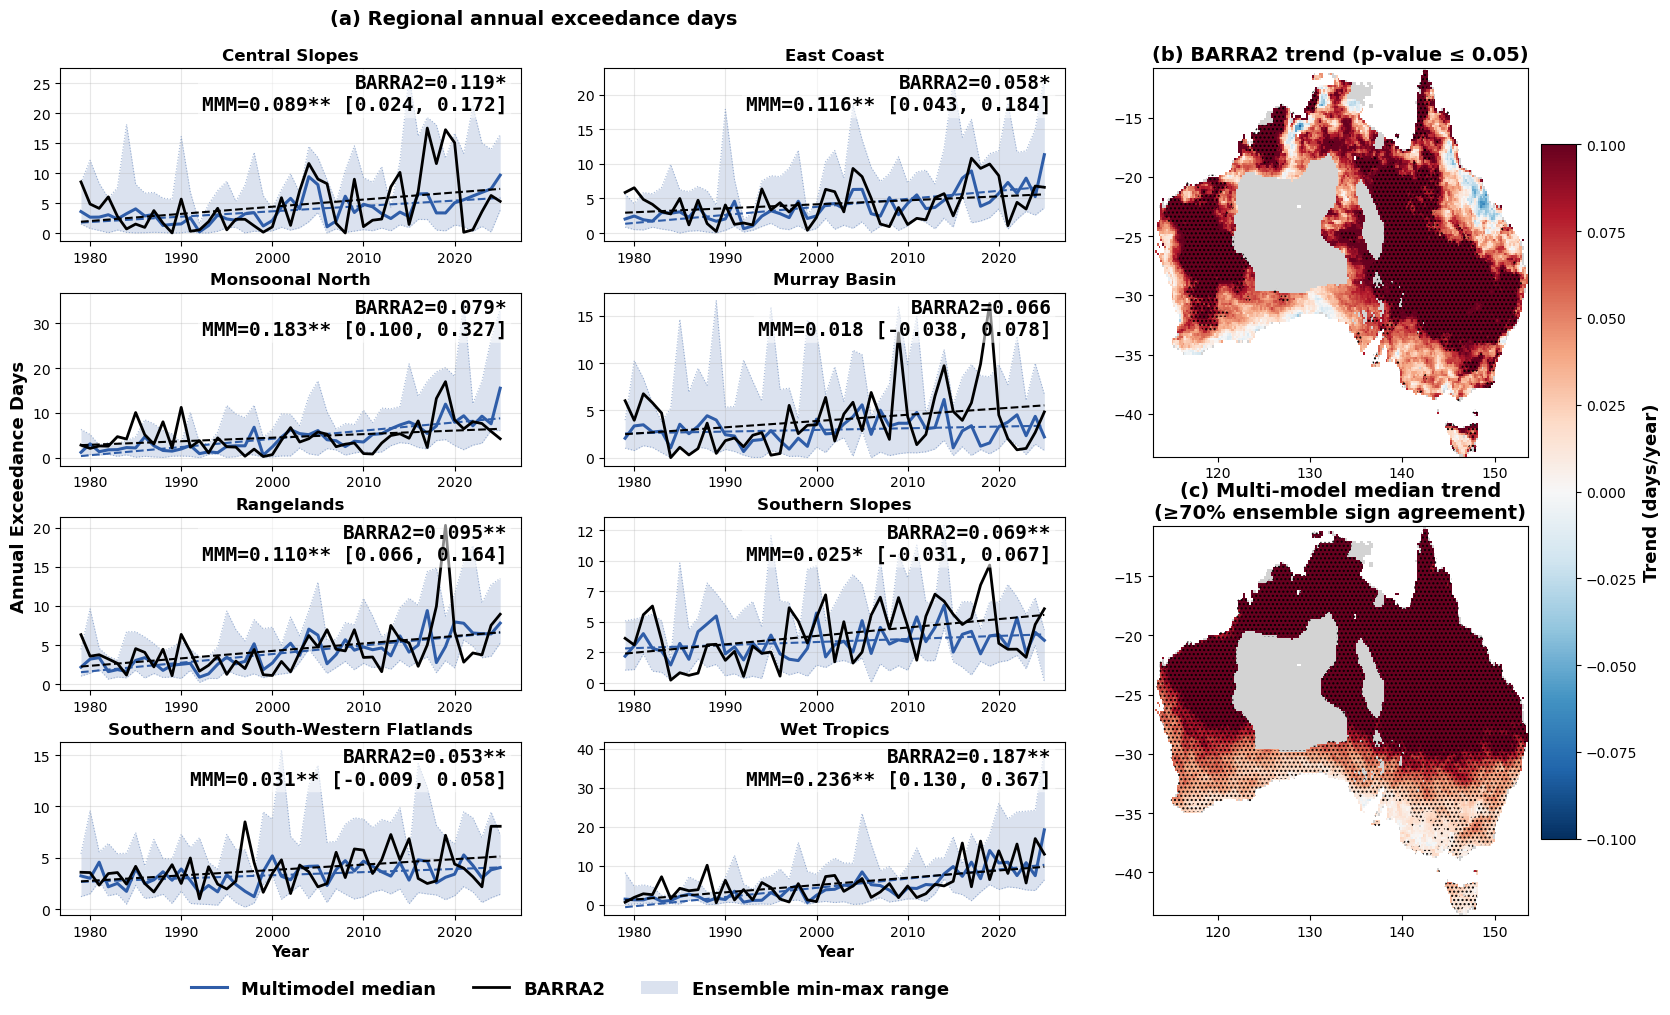

In [2]:
# ============================================================
# 6.5 COMBINED VISUALISATION -tas
# LEFT: NRM TIMESERIES (from redesign 5.2 style)
# RIGHT: BARRA2 + MMM TREND MAPS + exclude 
# 
# ============================================================

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.stats import linregress
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# SETTINGS
# ============================================================

summary_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries"
)

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2"
)

output_dir.mkdir(exist_ok=True)

# ============================================================
# MODELS
# ============================================================

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# LOAD LAND MASK
# ============================================================

mask_file = (
    "/scratch/dt6/xw9650/tmp/regridded/"
    "sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_"
    "NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"
)

land_mask = xr.open_dataset(mask_file)["sftlf"] > 50

# ============================================================
# Excluded region MASK
# ============================================================
mask_region = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/original_awra_awap_mask.nc')

def regrid_mask(mask, target_data):
 
    mask = mask.sortby('lat')
 
    max_lat = mask['lat'].max().values
    min_lat = mask['lat'].min().values
    max_lon = mask['lon'].max().values
    min_lon = mask['lon'].min().values
 
    mask = mask.astype(int)
 
    target_data = target_data.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    regridded_mask = mask.interp_like(target_data, method='nearest')
    new_access_mask = regridded_mask.astype(bool)
 
    return new_access_mask


# ============================================================
# TREND FUNCTION
# ============================================================

def compute_trend(years, values):

    mask = np.isfinite(values)

    years = years[mask]
    values = values[mask]

    if len(years) < 3:
        return np.nan, np.nan

    res = linregress(years, values)

    return res.slope, res.pvalue


# ============================================================
# SIGNIFICANCE STARS
# ============================================================

def stars(p):

    if np.isnan(p):
        return ""

    if p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# LOAD BARRA2 SUMMARY
# ============================================================

barra2_file = summary_dir / "tas_BARRA2_summary_1979_2025.parquet"

barra2_df = pd.read_parquet(barra2_file)

# ============================================================
# LOAD MODEL SUMMARIES
# ============================================================

ensemble_data = {}

for gcm, rcm in product(gcms, rcms):

    file = (
        summary_dir /
        f"tas_{gcm}_{rcm}_summary_1979_2025.parquet"
    )

    if not file.exists():

        print(f"Missing:\n{file}")
        continue

    ensemble_data[f"{gcm}_{rcm}"] = (
        pd.read_parquet(file)
    )

# ============================================================
# DETECT NRMS
# ============================================================

nrms = sorted(barra2_df["NRM"].unique())

print("Detected NRMs:")
print(nrms)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(20, 11)
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[2.2, 1],
    height_ratios=[1, 1],
    wspace=0.12,
    hspace=0.18
)

# ============================================================
# LEFT PANEL SUBGRID
# ============================================================

left_gs = gs[:, 0].subgridspec(
    4,
    2,
    wspace=0.18,
    hspace=0.30
)

axes = []

for i in range(len(nrms)):

    row = i // 2
    col = i % 2

    axes.append(
        fig.add_subplot(left_gs[row, col])
    )

# ============================================================
# RIGHT MAP PANELS
# ============================================================

ax_barra2 = fig.add_subplot(gs[0, 1])
ax_mmm = fig.add_subplot(gs[1, 1])

# ============================================================
# STORAGE
# ============================================================

trend_rows = []

# ============================================================
# MAIN LOOP
# ============================================================

for i, (ax, nrm) in enumerate(zip(axes, nrms)):

    ensemble_dfs = []

    # ========================================================
    # COLLECT ENSEMBLE MEMBERS
    # ========================================================

    for member_name, df in ensemble_data.items():

        df_nrm = df[
            df["NRM"] == nrm
        ][[
            "year",
            "annual_exceedance_days"
        ]].copy()

        if df_nrm.empty:
            continue

        df_nrm.rename(
            columns={
                "annual_exceedance_days": member_name
            },
            inplace=True
        )

        ensemble_dfs.append(
            df_nrm.set_index("year")
        )

    if not ensemble_dfs:
        continue

    # ========================================================
    # CREATE ENSEMBLE
    # ========================================================

    df_ensemble = pd.concat(
        ensemble_dfs,
        axis=1
    )

    years = df_ensemble.index.values

    # ========================================================
    # ENSEMBLE STATISTICS
    # ========================================================

    ensemble_median = (
        df_ensemble.median(axis=1)
    )

    ensemble_min = (
        df_ensemble.min(axis=1)
    )

    ensemble_max = (
        df_ensemble.max(axis=1)
    )

    # ========================================================
    # ENSEMBLE MIN-MAX SPREAD
    # ========================================================

    ax.fill_between(
        years,
        ensemble_min,
        ensemble_max,
        color="#4C72B0",
        alpha=0.20,
        linewidth=0,
        zorder=1
    )

    # OPTIONAL:
    # show min/max boundaries more clearly

    ax.plot(
        years,
        ensemble_min,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    ax.plot(
        years,
        ensemble_max,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    # ========================================================
    # MULTIMODEL MEDIAN
    # ========================================================

    ax.plot(
        years,
        ensemble_median,
        color="#2F5DA8",
        linewidth=2.2,
        label="Multimodel median",
        zorder=3
    )

    # ========================================================
    # MODEL TRENDS
    # ========================================================

    ensemble_slopes = []

    for col in df_ensemble.columns:

        slope_i, p_i = compute_trend(
            years,
            df_ensemble[col].values
        )

        ensemble_slopes.append(slope_i)

        trend_rows.append({
            "NRM": nrm,
            "Source": col,
            "Slope": slope_i,
            "p_value": p_i
        })

    mod_slope, mod_p = compute_trend(
        years,
        ensemble_median.values
    )

    ens_min = np.nanmin(ensemble_slopes)
    ens_max = np.nanmax(ensemble_slopes)

    trend_rows.append({
        "NRM": nrm,
        "Source": "Multimodel median",
        "Slope": mod_slope,
        "p_value": mod_p
    })

    # ========================================================
    # MULTIMODEL TREND LINE
    # ========================================================

    if np.isfinite(mod_slope):

        fit_mod = (
            mod_slope * years
            + np.mean(
                ensemble_median
                - mod_slope * years
            )
        )

        ax.plot(
            years,
            fit_mod,
            color="#2F5DA8",
            linestyle="--",
            linewidth=1.5,
            zorder=4
        )

    # ========================================================
    # BARRA2
    # ========================================================

    df_barra2 = barra2_df[
        barra2_df["NRM"] == nrm
    ]

    barra2_slope = np.nan
    barra2_p = np.nan

    if not df_barra2.empty:

        ax.plot(
            df_barra2["year"],
            df_barra2["annual_exceedance_days"],
            color="black",
            linewidth=2,
            label="BARRA2",
            zorder=5
        )

        x_barra2 = df_barra2["year"].values

        y_barra2 = df_barra2[
            "annual_exceedance_days"
        ].values

        barra2_slope, barra2_p = compute_trend(
            x_barra2,
            y_barra2
        )

        trend_rows.append({
            "NRM": nrm,
            "Source": "BARRA2",
            "Slope": barra2_slope,
            "p_value": barra2_p
        })

        if np.isfinite(barra2_slope):

            fit_barra2 = (
                barra2_slope * x_barra2
                + np.mean(
                    y_barra2
                    - barra2_slope * x_barra2
                )
            )

            ax.plot(
                x_barra2,
                fit_barra2,
                color="black",
                linestyle="--",
                linewidth=1.5,
                zorder=6
            )

    # ========================================================
    # PANEL TEXT
    # ========================================================

    text_str = (
        f"BARRA2={barra2_slope:.3f}{stars(barra2_p)}\n"
        f"MMM={mod_slope:.3f}{stars(mod_p)} "
        f"[{ens_min:.3f}, {ens_max:.3f}]"
    )

    # ax.text(
    #     0.97,
    #     0.97,
    #     text_str,
    #     transform=ax.transAxes,
    #     ha="right",
    #     va="top",
    #     fontsize=7.8,
    #     bbox=dict(
    #         facecolor="white",
    #         alpha=0.75,
    #         edgecolor="none",
    #         pad=1.5
    #     ),
    #     zorder=10
    # )
    ax.text(
        0.97,
        0.97,
        text_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight='bold',
        family="monospace",
        linespacing=1.2,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            alpha=0.55,
            edgecolor="none"
        ),
        zorder=10
    )
    # ========================================================
    # PANEL STYLE
    # ========================================================

    ax.set_title(
        nrm,
        fontsize=12,
        fontweight="bold"
    )

    row = i // 2

    if row == 3:

        ax.set_xlabel(
            "Year",
            fontsize=11,
            fontweight="bold"
        )

    else:

        ax.set_xlabel("")

    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FormatStrFormatter("%d")
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    ax.grid(
        alpha=0.3
    )

# ============================================================
# GLOBAL Y LABEL
# ============================================================

fig.text(
    0.1,
    0.5,
    "Annual Exceedance Days",
    va="center",
    rotation="vertical",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# LOAD TREND MAPS
# ============================================================

barra2_ds = xr.open_dataset(
    trend_dir / "tas_BARRA2_trend_1979_2025.nc"
)

mmm_ds = xr.open_dataset(
    trend_dir / "tas_MMM_trend_1979_2025.nc"
)

# ============================================================
# ALIGN MASK
# ============================================================

barra2_ds, land_mask_aligned = xr.align(
    barra2_ds,
    land_mask,
    join="inner"
)

mmm_ds, land_mask_aligned = xr.align(
    mmm_ds,
    land_mask,
    join="inner"
)

barra2_land = barra2_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
barra2_land_mask = regrid_mask(mask_region, barra2_land)
barra2_land_masked = barra2_land.where(barra2_land_mask)
    


mmm_land = mmm_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
mmm_land_mask = regrid_mask(mask_region, mmm_land)
mmm_land_masked = mmm_land.where(mmm_land_mask)
    
# ============================================================
# PLOT MAPS
# ============================================================

vmin = -0.1
vmax = 0.1

# ============================================================
# CREATE EXCLUDED LAND MASK
# ============================================================

# valid region mask after regridding
# True  = keep
# False = excluded

excluded_barra2 = (
    land_mask_aligned &
    (~barra2_land_mask)
)

excluded_mmm = (
    land_mask_aligned &
    (~mmm_land_mask)
)

# ============================================================
# LIGHT GRAY COLORMAP
# ============================================================

from matplotlib.colors import ListedColormap

gray_cmap = ListedColormap(["lightgray"])

# ============================================================
# PLOT EXCLUDED LAND FIRST
# ============================================================

xr.where(
    excluded_barra2,
    1,
    np.nan
).plot(
    ax=ax_barra2,
    cmap=gray_cmap,
    add_colorbar=False
)

xr.where(
    excluded_mmm,
    1,
    np.nan
).plot(
    ax=ax_mmm,
    cmap=gray_cmap,
    add_colorbar=False
)

# ============================================================
# OVERLAY ACTUAL TREND DATA
# ============================================================

barra2_plot = barra2_land_masked.trend.plot(
    ax=ax_barra2,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

# ============================================================
# BARRA2 SIGNIFICANCE STIPPLING (p <= 0.05)
# ============================================================

if "p_value" in barra2_land_masked:

    sig = barra2_land_masked["p_value"] <= 0.05

    step = 3  # adjust density (2–5 usually works well)

    sig_sparse = sig[::step, ::step]

    ax_barra2.contourf(
        barra2_land_masked.lon[::step],
        barra2_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
        # transform=barra2_plot.axes.get_transform("data")  # optional safety
    )
    

mmm_plot = mmm_land_masked.MMM_trend.plot(
    ax=ax_mmm,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
# ============================================================
# REMOVE AXIS LABELS (RIGHT PANELS)
# ============================================================

for ax in [ax_barra2, ax_mmm]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.tick_params(
    #     axis="both",
    #     which="both",
    #     length=3,      # removes tick marks
    #     labelbottom=False,
    #     labelleft=False
    # )
# # ============================================================
# # SIGN AGREEMENT STIPPLING
# # ============================================================

# if "sign_agreement" in mmm_land:

#     sig = mmm_land["sign_agreement"] >= 0.7

#     yy, xx = np.where(sig.values)

#     # reduced density for visibility

#     step = 10

#     yy = yy[::step]
#     xx = xx[::step]

#     ax_mmm.scatter(
#         mmm_land.lon.values[xx],
#         mmm_land.lat.values[yy],
#         s=0.7,
#         color="black",
#         alpha=0.28
#     )


# ============================================================
# HATCHING (70% AGREEMENT)
# ============================================================

if "sign_agreement" in mmm_land_masked:

    sig = mmm_land_masked["sign_agreement"] >= 0.7

    step = 2  # try 2, 3, 4, 5 depending on resolution

    sig_sparse = sig[::step, ::step]

    ax_mmm.contourf(
        mmm_land_masked.lon[::step],
        mmm_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
    )
    
# ============================================================
# MAP TITLES
# ============================================================

ax_barra2.set_title(
    "(b) BARRA2 trend (p-value ≤ 0.05)",
    fontsize=14,
    fontweight="bold"
)

ax_mmm.set_title(
    "(c) Multi-model median trend\n"
    "(≥70% ensemble sign agreement)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    barra2_plot,
    ax=[ax_barra2, ax_mmm],
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "Trend (days/year)",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# PANEL LABEL
# ============================================================

fig.text(
    0.26,
    0.92,
    "(a) Regional annual exceedance days",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# FIGURE LEGEND
# ============================================================

legend_handles = [

    plt.Line2D(
        [0], [0],
        color="#2F5DA8",
        linewidth=2.2
    ),

    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=2
    ),

    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor="#4C72B0",
        alpha=0.20
    )
]

# fig.legend(
#     legend_handles,
#     [
#         "Multimodel median",
#         "BARRA2",
#         "Ensemble min-max range"
#     ],
#     loc="lower center",
#     ncol=3,
#     fontsize=11,
#     frameon=False
# )
# ============================================================
# FIGURE LEGEND (LEFT PANEL ONLY)--CHANGE1
# ============================================================

# Get bounding box of left panel group
left_bbox = gs[:, 0].get_position(fig)

legend_handles = [

    plt.Line2D([0], [0], color="#2F5DA8", linewidth=2.2),
    plt.Line2D([0], [0], color="black", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, facecolor="#4C72B0", alpha=0.20)

]

legend=fig.legend(
    legend_handles,
    [
        "Multimodel median",
        "BARRA2",
        "Ensemble min-max range"
    ],
    loc="lower center",
    # bbox_to_anchor=(
    #     (left_bbox.x0 + left_bbox.x1) / 2,  # center x of LEFT panel
    #     left_bbox.y0 - 0.02                 # slightly below left panel
    # ),
    bbox_to_anchor=(0.38, 0.02),  # 👈 move into left panel bottom
    ncol=3,
    fontsize=13, #increase font size (CHANGE3),
    frameon=False
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# ============================================================
# SAVE TREND TABLE
# ============================================================

trend_df = pd.DataFrame(trend_rows)

trend_df["Slope"] = (
    trend_df["Slope"]
    .astype(float)
    .round(4)
)

trend_df["p_value"] = (
    trend_df["p_value"]
    .astype(float)
    .round(4)
)

trend_df["Slope_sig"] = (
    trend_df["Slope"].astype(str)
    + trend_df["p_value"].apply(stars)
)

trend_csv = (
    output_dir /
    "tas_annual_exceedance_trends_1979_2025.csv"
)

trend_xlsx = (
    output_dir /
    "tas_annual_exceedance_trends_1979_2025.xlsx"
)

trend_df.to_csv(
    trend_csv,
    index=False
)

trend_df.to_excel(
    trend_xlsx,
    index=False
)

print(f"Saved trend table:\n{trend_csv}")

# ============================================================
# SAVE FIGURE
# ============================================================

plt.tight_layout(
    rect=[0.05, 0.04, 1, 0.95]
)

fig_file = (
    output_dir /
    "tas_combined_timeseries_maps_1979_2025.png"
)

fig.savefig(
    fig_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure:\n{fig_file}")

plt.show()

In [9]:
# redesign 7.1--hurs
# ============================================================
# COMPUTE ANNUAL HURS EXCEEDANCE SUMMARIES
# DASK-OPTIMISED VERSION
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

barra2_file = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
    "hurs_univ_exceed_1979_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/"
    "hurs_{gcm}_{rcm}_ssp370_univ_exceed_1979_2025.nc"
)

mask_shapefile = (
    "/scratch/dt6/xw9650/tmp/reference_data/"
    "NRM_clusters/NRM_clusters.shp"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2"
)

summary_dir = output_dir / "summaries"

output_dir.mkdir(exist_ok=True)

summary_dir.mkdir(exist_ok=True)

mask_nc = output_dir / "nrm_mask.nc"

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# CREATE REGION MASK ONCE
# ============================================================

def create_nrm_mask(
    sample_file,
    shapefile,
    out_file
):

    print("Creating NRM mask...")

    ds = xr.open_dataset(sample_file)

    gdf = (
        gpd.read_file(shapefile)
        .to_crs("EPSG:4326")
    )

    gdf = gdf[
        gdf.geometry.notnull()
    ]

    regions = regionmask.Regions(
        outlines=list(gdf.geometry),
        names=gdf["label"].tolist(),
        numbers=list(range(len(gdf)))
    )

    mask = regions.mask(
        ds.lon,
        ds.lat
    )

    mask.name = "nrm_mask"

    mask.to_netcdf(out_file)

    print(f"Saved mask:\n{out_file}")

# ============================================================
# CREATE MASK IF MISSING
# ============================================================

if not mask_nc.exists():

    create_nrm_mask(
        barra2_file,
        mask_shapefile,
        mask_nc
    )

# ============================================================
# LOAD MASK
# ============================================================

mask = xr.open_dataarray(mask_nc)

# ============================================================
# REGION NAMES
# ============================================================

gdf_regions = (
    gpd.read_file(mask_shapefile)
    .to_crs("EPSG:4326")
)

region_names = {
    i: name
    for i, name in enumerate(
        gdf_regions["label"].tolist()
    )
}

# ============================================================
# SUMMARY FUNCTION
# ============================================================

def summarise_annual_exceedance(
    nc_file,
    out_file,
    source_name
):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"time": 365}
    )

    # ========================================================
    # AUTO-DETECT VARIABLE
    # ========================================================

    var_name = list(ds.data_vars)[0]

    da = ds[var_name]

    # ========================================================
    # CONVERT BOOLEAN TO INTEGER
    # ========================================================

    if da.dtype == bool:

        da = da.astype("int16")

    # ========================================================
    # ANNUAL SUM
    # ========================================================

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # ========================================================
    # REGION IDS
    # ========================================================

    region_ids = np.unique(
        mask.values[
            np.isfinite(mask.values)
        ]
    ).astype(int)

    all_rows = []

    # ========================================================
    # LOOP REGIONS
    # ========================================================

    for region_id in region_ids:

        regional = (
            annual
            .where(mask == region_id)
            .mean(dim=["lat", "lon"])
        )

        regional = regional.compute()

        years = regional["time.year"].values

        values = regional.values

        rows = pd.DataFrame({
            "NRM": region_names[region_id],
            "year": years.astype(int),
            "annual_exceedance_days": values.astype(float),
            "Source": source_name
        })

        all_rows.append(rows)

    # ========================================================
    # CONCATENATE
    # ========================================================

    df = pd.concat(
        all_rows,
        ignore_index=True
    )

    # ========================================================
    # SAVE
    # ========================================================

    df.to_parquet(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# CREATE TASKS
# ============================================================

tasks = []

# ============================================================
# BARRA2 TASK
# ============================================================

barra2_out = (
    summary_dir /
    "hurs_BARRA2_summary_1979_2025.parquet"
)

tasks.append(
    delayed(
        summarise_annual_exceedance
    )(
        barra2_file,
        barra2_out,
        "BARRA2"
    )
)

# ============================================================
# MODEL TASKS
# ============================================================

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():

        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        summary_dir /
        f"hurs_{gcm}_{rcm}_summary_1979_2025.parquet"
    )

    source_name = f"{gcm}_{rcm}"

    tasks.append(
        delayed(
            summarise_annual_exceedance
        )(
            model_file,
            out_file,
            source_name
        )
    )

# ============================================================
# RUN TASKS
# ============================================================

results = compute(*tasks)

print("\nFinished summaries:")

for r in results:
    print(r)

# ============================================================
# CLOSE CLIENT
# ============================================================

client.close()

<Client: 'tcp://127.0.0.1:43807' processes=8 threads=8, memory=59.60 GiB>

Finished summaries:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/hurs_BARRA2_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/hurs_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/hurs_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/hurs_EC-Earth3-Veg_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/hurs_EC-Earth3-Veg_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/hurs_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/hurs_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/hurs_NorESM2-MM_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratc

In [10]:
#7.2 -hurs
# ============================================================
# COMPUTE GRIDCELL TRENDS + SIGNIFICANCE (MINIMAL CHANGE)
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import xarray as xr
from dask import delayed, compute
from dask.distributed import Client
from scipy.stats import linregress   # ✅ ADDED


# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)


# ============================================================
# SETTINGS
# ============================================================

START_YEAR = 1979
END_YEAR = 2025

obs_file = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
    "hurs_univ_exceed_1979_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/"
    "hurs_{gcm}_{rcm}_ssp370_univ_exceed_1979_2025.nc"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

output_dir.mkdir(parents=True, exist_ok=True)

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]


# ============================================================
# TREND FUNCTION
# ============================================================

def compute_gridcell_trend(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    # --------------------------------------------------------
    # OPEN
    # --------------------------------------------------------

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # ============================================================
    # FILTER TIME (CRITICAL FIX)
    # ============================================================

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    # --------------------------------------------------------
    # BOOLEAN -> INTEGER
    # --------------------------------------------------------

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL EXCEEDANCE DAYS
    # --------------------------------------------------------

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # --------------------------------------------------------
    # YEAR COORDINATE
    # --------------------------------------------------------

    annual = annual.assign_coords(
        year=("time", annual["time.year"].values)
    )

    # --------------------------------------------------------
    # TREND (PIXEL-WISE)
    # --------------------------------------------------------

    trend_ds = annual.polyfit(
        dim="year",
        deg=1,
        skipna=True
    )

    slope = trend_ds.polyfit_coefficients.sel(degree=1)
    slope.name = "trend"

    slope.attrs["description"] = (
        f"Trend in annual exceedance days "
        f"(days/year), {START_YEAR}-{END_YEAR}"
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    slope.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file
# ============================================================
# TREND FUNCTION (UPDATED to include p-value)
# ============================================================

def compute_gridcell_trend_with_pvalue(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # --------------------------------------------------------
    # TIME FILTER
    # --------------------------------------------------------

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL SUM
    # --------------------------------------------------------

    annual = da.resample(time="YE").sum(dim="time")

    years = annual["time.year"].values

    # ========================================================
    # MINIMAL CHANGE: ADD SIGNIFICANCE VIA LINREGRESS
    # ========================================================

    def _trend(y):

        if np.all(np.isnan(y)):
            return np.array([np.nan, np.nan])

        slope, intercept, r, p, stderr = linregress(years, y)

        return np.array([slope, p])   # slope + p-value

    result = xr.apply_ufunc(
        _trend,
        annual,
        input_core_dims=[["time"]],
        output_core_dims=[["stat"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={"stat": 2}
    )

    slope = result.isel(stat=0)
    pval = result.isel(stat=1)

    slope.name = "trend"
    pval.name = "p_value"

    slope.attrs["description"] = (
        f"Trend in annual exceedance (days/year), "
        f"{START_YEAR}-{END_YEAR}"
    )

    pval.attrs["description"] = "p-value of linear trend"

    # --------------------------------------------------------
    # SAVE (NOW DATASET INSTEAD OF SINGLE VARIABLE)
    # --------------------------------------------------------

    out_ds = xr.Dataset({
        "trend": slope,
        "p_value": pval
    })

    out_ds.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file


# ============================================================
# TASKS
# ============================================================

tasks = []

obs_out = output_dir / "hurs_BARRA2_trend_1979_2025.nc"

tasks.append(
    delayed(compute_gridcell_trend_with_pvalue)(
        obs_file,
        obs_out
    )
)


for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():
        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        output_dir /
        f"hurs_{gcm}_{rcm}_trend_1979_2025.nc"
    )

    tasks.append(
        delayed(compute_gridcell_trend)(
            model_file,
            out_file
        )
    )


# ============================================================
# RUN
# ============================================================

results = compute(*tasks)

print("\nFinished trend calculations:")
print(results)


client.close()

<Client: 'tcp://127.0.0.1:41461' processes=8 threads=8, memory=59.60 GiB>


/jobfs/172691317.gadi-pbs/ipykernel_976367/936543917.py:198: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.



Finished trend calculations:
(PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_BARRA2_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_EC-Earth3-Veg_NARCliM2-0-WRF412R3_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_EC-Earth3-Veg_NARCliM2-0-WRF412R5_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_NorESM2-MM_NARCliM2-0-WRF412R3_trend_1979_2025.nc'), PosixPa

In [11]:
#7.2.2 +add sign agreement --tas
# ============================================================
# MULTI-MODEL MEDIAN TREND
# + SIGN AGREEMENT
# ============================================================

import xarray as xr
import numpy as np

from pathlib import Path

# ============================================================
# PATHS
# ============================================================

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

# ============================================================
# LOAD ALL MODEL TREND FILES
# ============================================================

model_trends = []

model_names = []

for f in trend_dir.glob("hurs*_trend_1979_2025.nc"):

    if "BARRA2" in f.name:
        continue

    if "MMM" in f.name:
        continue

    da = xr.open_dataarray(f)

    model_trends.append(da)

    model_names.append(f.stem)

print(f"Loaded {len(model_trends)} model trend files")

# ============================================================
# STACK MODELS
# ============================================================

stacked = xr.concat(
    model_trends,
    dim="model"
)

stacked["model"] = model_names

# ============================================================
# MULTI-MODEL MEDIAN
# ============================================================

mmm_trend = stacked.median(dim="model")

mmm_trend.name = "MMM_trend"

# ============================================================
# SIGN AGREEMENT
# ============================================================

# Positive trend models
n_positive = (stacked > 0).sum(dim="model")

# Negative trend models
n_negative = (stacked < 0).sum(dim="model")

# Total valid models
n_total = np.isfinite(stacked).sum(dim="model")

# Maximum agreement
max_agree = xr.ufuncs.maximum(
    n_positive,
    n_negative
)

# Fraction agreeing on sign
sign_agreement = (
    max_agree / n_total
)

sign_agreement.name = "sign_agreement"

sign_agreement.attrs = {
    "description":
        "Fraction of ensemble members agreeing on trend sign"
}

# ============================================================
# STIPPLE MASK
# ============================================================

stippling = sign_agreement >= 0.7

stippling.name = "stippling"

stippling.attrs = {
    "description":
        "True where >=70% of models agree on trend sign"
}

# ============================================================
# CREATE OUTPUT DATASET
# ============================================================

ds_out = xr.Dataset({

    "MMM_trend": mmm_trend,

    "sign_agreement": sign_agreement,

    "stippling": stippling

})

# ============================================================
# ATTRIBUTES
# ============================================================

ds_out["MMM_trend"].attrs = {
    "description":
        "Multimodel median trend (days/year)"
}

# ============================================================
# SAVE
# ============================================================

mmm_out = trend_dir / "hurs_MMM_trend_1979_2025.nc"

ds_out.to_netcdf(mmm_out)

print(f"Saved multimodel median trend:\n{mmm_out}")

Loaded 10 model trend files
Saved multimodel median trend:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/hurs_MMM_trend_1979_2025.nc


Detected NRMs:
['Central Slopes', 'East Coast', 'Monsoonal North', 'Murray Basin', 'Rangelands', 'Southern Slopes', 'Southern and South-Western Flatlands', 'Wet Tropics']
Saved trend table:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/hurs_annual_exceedance_trends_1979_2025.csv


/jobfs/177773252.gadi-pbs/ipykernel_2216010/3802292857.py:923: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


Saved figure:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/hurs_combined_timeseries_maps_1979_2025.png


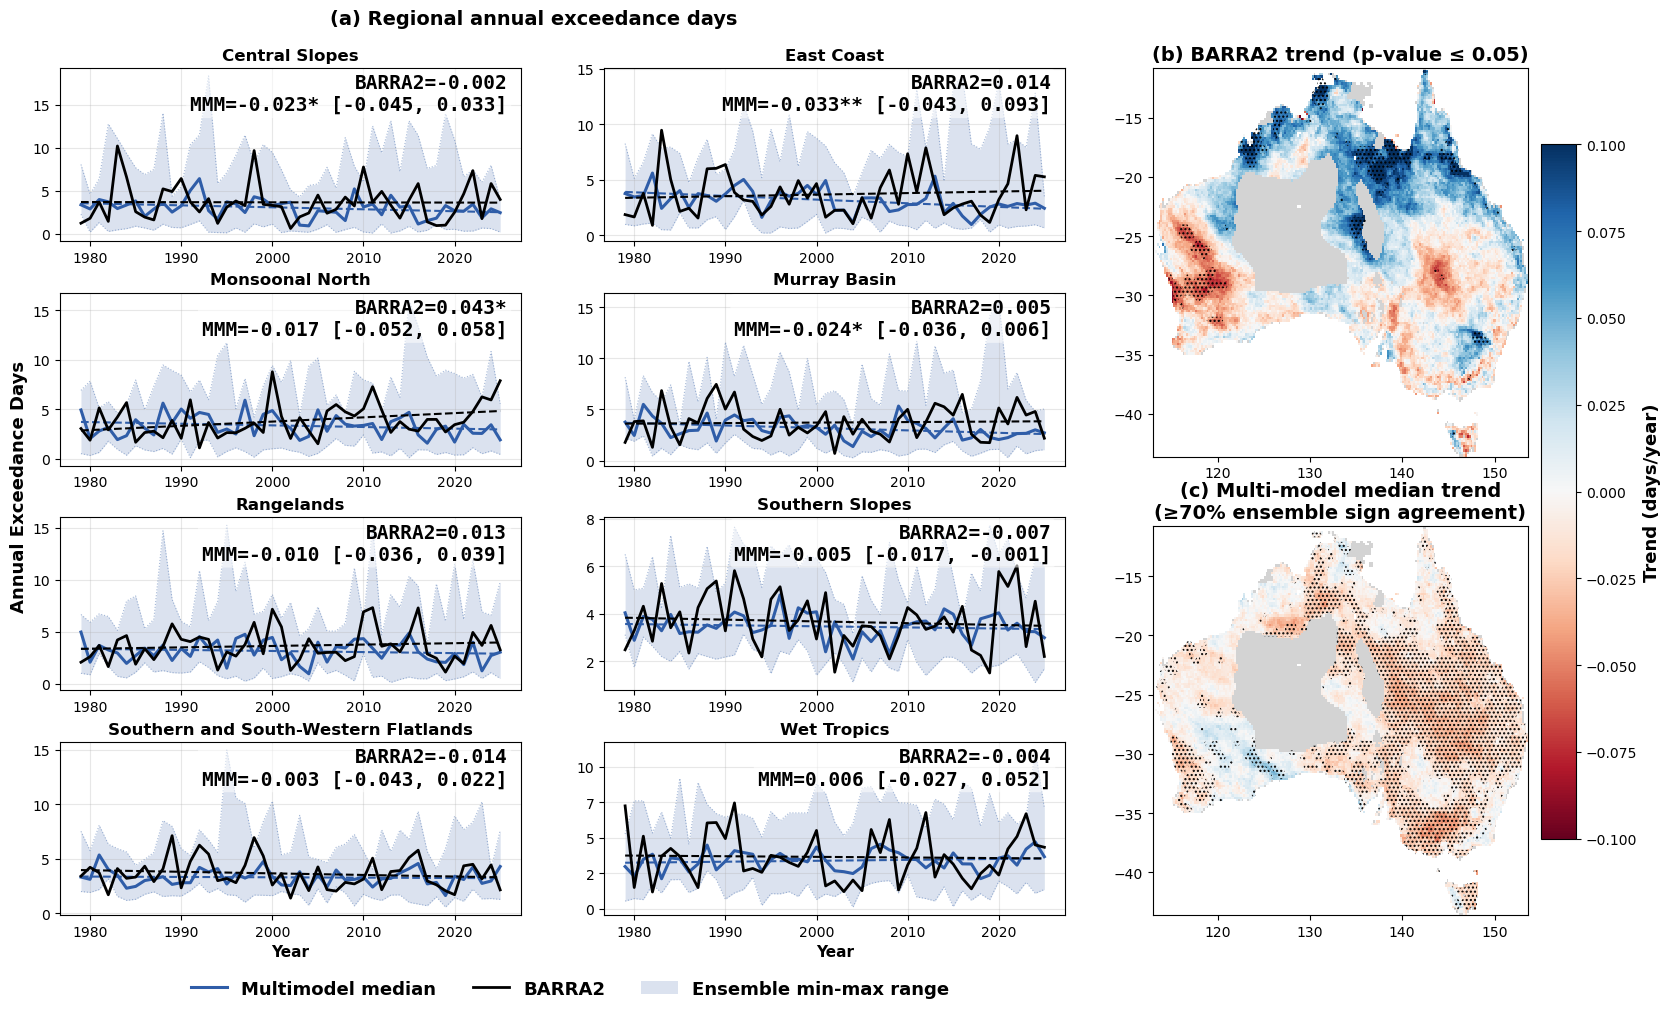

In [19]:
# ============================================================
# 7.5 COMBINED VISUALISATION -hurs
# LEFT: NRM TIMESERIES (from redesign 5.2 style)
# RIGHT: BARRA2 + MMM TREND MAPS + exclude 
# 
# ============================================================

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.stats import linregress
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# SETTINGS
# ============================================================

summary_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries"
)

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2"
)

output_dir.mkdir(exist_ok=True)

# ============================================================
# MODELS
# ============================================================

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# LOAD LAND MASK
# ============================================================

mask_file = (
    "/scratch/dt6/xw9650/tmp/regridded/"
    "sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_"
    "NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"
)

land_mask = xr.open_dataset(mask_file)["sftlf"] > 50

# ============================================================
# Excluded region MASK
# ============================================================
mask_region = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/original_awra_awap_mask.nc')

def regrid_mask(mask, target_data):
 
    mask = mask.sortby('lat')
 
    max_lat = mask['lat'].max().values
    min_lat = mask['lat'].min().values
    max_lon = mask['lon'].max().values
    min_lon = mask['lon'].min().values
 
    mask = mask.astype(int)
 
    target_data = target_data.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    regridded_mask = mask.interp_like(target_data, method='nearest')
    new_access_mask = regridded_mask.astype(bool)
 
    return new_access_mask


# ============================================================
# TREND FUNCTION
# ============================================================

def compute_trend(years, values):

    mask = np.isfinite(values)

    years = years[mask]
    values = values[mask]

    if len(years) < 3:
        return np.nan, np.nan

    res = linregress(years, values)

    return res.slope, res.pvalue


# ============================================================
# SIGNIFICANCE STARS
# ============================================================

def stars(p):

    if np.isnan(p):
        return ""

    if p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# LOAD BARRA2 SUMMARY
# ============================================================

barra2_file = summary_dir / "hurs_BARRA2_summary_1979_2025.parquet"

barra2_df = pd.read_parquet(barra2_file)

# ============================================================
# LOAD MODEL SUMMARIES
# ============================================================

ensemble_data = {}

for gcm, rcm in product(gcms, rcms):

    file = (
        summary_dir /
        f"hurs_{gcm}_{rcm}_summary_1979_2025.parquet"
    )

    if not file.exists():

        print(f"Missing:\n{file}")
        continue

    ensemble_data[f"{gcm}_{rcm}"] = (
        pd.read_parquet(file)
    )

# ============================================================
# DETECT NRMS
# ============================================================

nrms = sorted(barra2_df["NRM"].unique())

print("Detected NRMs:")
print(nrms)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(20, 11)
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[2.2, 1],
    height_ratios=[1, 1],
    wspace=0.12,
    hspace=0.18
)

# ============================================================
# LEFT PANEL SUBGRID
# ============================================================

left_gs = gs[:, 0].subgridspec(
    4,
    2,
    wspace=0.18,
    hspace=0.30
)

axes = []

for i in range(len(nrms)):

    row = i // 2
    col = i % 2

    axes.append(
        fig.add_subplot(left_gs[row, col])
    )

# ============================================================
# RIGHT MAP PANELS
# ============================================================

ax_barra2 = fig.add_subplot(gs[0, 1])
ax_mmm = fig.add_subplot(gs[1, 1])

# ============================================================
# STORAGE
# ============================================================

trend_rows = []

# ============================================================
# MAIN LOOP
# ============================================================

for i, (ax, nrm) in enumerate(zip(axes, nrms)):

    ensemble_dfs = []

    # ========================================================
    # COLLECT ENSEMBLE MEMBERS
    # ========================================================

    for member_name, df in ensemble_data.items():

        df_nrm = df[
            df["NRM"] == nrm
        ][[
            "year",
            "annual_exceedance_days"
        ]].copy()

        if df_nrm.empty:
            continue

        df_nrm.rename(
            columns={
                "annual_exceedance_days": member_name
            },
            inplace=True
        )

        ensemble_dfs.append(
            df_nrm.set_index("year")
        )

    if not ensemble_dfs:
        continue

    # ========================================================
    # CREATE ENSEMBLE
    # ========================================================

    df_ensemble = pd.concat(
        ensemble_dfs,
        axis=1
    )

    years = df_ensemble.index.values

    # ========================================================
    # ENSEMBLE STATISTICS
    # ========================================================

    ensemble_median = (
        df_ensemble.median(axis=1)
    )

    ensemble_min = (
        df_ensemble.min(axis=1)
    )

    ensemble_max = (
        df_ensemble.max(axis=1)
    )

    # ========================================================
    # ENSEMBLE MIN-MAX SPREAD
    # ========================================================

    ax.fill_between(
        years,
        ensemble_min,
        ensemble_max,
        color="#4C72B0",
        alpha=0.20,
        linewidth=0,
        zorder=1
    )

    # OPTIONAL:
    # show min/max boundaries more clearly

    ax.plot(
        years,
        ensemble_min,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    ax.plot(
        years,
        ensemble_max,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    # ========================================================
    # MULTIMODEL MEDIAN
    # ========================================================

    ax.plot(
        years,
        ensemble_median,
        color="#2F5DA8",
        linewidth=2.2,
        label="Multimodel median",
        zorder=3
    )

    # ========================================================
    # MODEL TRENDS
    # ========================================================

    ensemble_slopes = []

    for col in df_ensemble.columns:

        slope_i, p_i = compute_trend(
            years,
            df_ensemble[col].values
        )

        ensemble_slopes.append(slope_i)

        trend_rows.append({
            "NRM": nrm,
            "Source": col,
            "Slope": slope_i,
            "p_value": p_i
        })

    mod_slope, mod_p = compute_trend(
        years,
        ensemble_median.values
    )

    ens_min = np.nanmin(ensemble_slopes)
    ens_max = np.nanmax(ensemble_slopes)

    trend_rows.append({
        "NRM": nrm,
        "Source": "Multimodel median",
        "Slope": mod_slope,
        "p_value": mod_p
    })

    # ========================================================
    # MULTIMODEL TREND LINE
    # ========================================================

    if np.isfinite(mod_slope):

        fit_mod = (
            mod_slope * years
            + np.mean(
                ensemble_median
                - mod_slope * years
            )
        )

        ax.plot(
            years,
            fit_mod,
            color="#2F5DA8",
            linestyle="--",
            linewidth=1.5,
            zorder=4
        )

    # ========================================================
    # BARRA2
    # ========================================================

    df_barra2 = barra2_df[
        barra2_df["NRM"] == nrm
    ]

    barra2_slope = np.nan
    barra2_p = np.nan

    if not df_barra2.empty:

        ax.plot(
            df_barra2["year"],
            df_barra2["annual_exceedance_days"],
            color="black",
            linewidth=2,
            label="BARRA2",
            zorder=5
        )

        x_barra2 = df_barra2["year"].values

        y_barra2 = df_barra2[
            "annual_exceedance_days"
        ].values

        barra2_slope, barra2_p = compute_trend(
            x_barra2,
            y_barra2
        )

        trend_rows.append({
            "NRM": nrm,
            "Source": "BARRA2",
            "Slope": barra2_slope,
            "p_value": barra2_p
        })

        if np.isfinite(barra2_slope):

            fit_barra2 = (
                barra2_slope * x_barra2
                + np.mean(
                    y_barra2
                    - barra2_slope * x_barra2
                )
            )

            ax.plot(
                x_barra2,
                fit_barra2,
                color="black",
                linestyle="--",
                linewidth=1.5,
                zorder=6
            )

    # ========================================================
    # PANEL TEXT
    # ========================================================

    text_str = (
        f"BARRA2={barra2_slope:.3f}{stars(barra2_p)}\n"
        f"MMM={mod_slope:.3f}{stars(mod_p)} "
        f"[{ens_min:.3f}, {ens_max:.3f}]"
    )

    # ax.text(
    #     0.97,
    #     0.97,
    #     text_str,
    #     transform=ax.transAxes,
    #     ha="right",
    #     va="top",
    #     fontsize=7.8,
    #     bbox=dict(
    #         facecolor="white",
    #         alpha=0.75,
    #         edgecolor="none",
    #         pad=1.5
    #     ),
    #     zorder=10
    # )
    ax.text(
        0.97,
        0.97,
        text_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight='bold',
        family="monospace",
        linespacing=1.2,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            alpha=0.55,
            edgecolor="none"
        ),
        zorder=10
    )
    # ========================================================
    # PANEL STYLE
    # ========================================================

    ax.set_title(
        nrm,
        fontsize=12,
        fontweight="bold"
    )

    row = i // 2

    if row == 3:

        ax.set_xlabel(
            "Year",
            fontsize=11,
            fontweight="bold"
        )

    else:

        ax.set_xlabel("")

    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FormatStrFormatter("%d")
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    ax.grid(
        alpha=0.3
    )

# ============================================================
# GLOBAL Y LABEL
# ============================================================

fig.text(
    0.1,
    0.5,
    "Annual Exceedance Days",
    va="center",
    rotation="vertical",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# LOAD TREND MAPS
# ============================================================

barra2_ds = xr.open_dataset(
    trend_dir / "hurs_BARRA2_trend_1979_2025.nc"
)

mmm_ds = xr.open_dataset(
    trend_dir / "hurs_MMM_trend_1979_2025.nc"
)

# ============================================================
# ALIGN MASK
# ============================================================

barra2_ds, land_mask_aligned = xr.align(
    barra2_ds,
    land_mask,
    join="inner"
)

mmm_ds, land_mask_aligned = xr.align(
    mmm_ds,
    land_mask,
    join="inner"
)

barra2_land = barra2_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
barra2_land_mask = regrid_mask(mask_region, barra2_land)
barra2_land_masked = barra2_land.where(barra2_land_mask)
    


mmm_land = mmm_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
mmm_land_mask = regrid_mask(mask_region, mmm_land)
mmm_land_masked = mmm_land.where(mmm_land_mask)
    
# ============================================================
# PLOT MAPS
# ============================================================

vmin = - 0.1
vmax = 0.1

# ============================================================
# CREATE EXCLUDED LAND MASK
# ============================================================

# valid region mask after regridding
# True  = keep
# False = excluded

excluded_barra2 = (
    land_mask_aligned &
    (~barra2_land_mask)
)

excluded_mmm = (
    land_mask_aligned &
    (~mmm_land_mask)
)

# ============================================================
# LIGHT GRAY COLORMAP
# ============================================================

from matplotlib.colors import ListedColormap

gray_cmap = ListedColormap(["lightgray"])

# ============================================================
# PLOT EXCLUDED LAND FIRST
# ============================================================

xr.where(
    excluded_barra2,
    1,
    np.nan
).plot(
    ax=ax_barra2,
    cmap=gray_cmap,
    add_colorbar=False
)

xr.where(
    excluded_mmm,
    1,
    np.nan
).plot(
    ax=ax_mmm,
    cmap=gray_cmap,
    add_colorbar=False
)

# ============================================================
# OVERLAY ACTUAL TREND DATA
# ============================================================

barra2_plot = barra2_land_masked.trend.plot(
    ax=ax_barra2,
    cmap="RdBu", #BLUE = positive / increasing trend (higher humidity change);RED  = negative / decreasing trend
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

# ============================================================
# BARRA2 SIGNIFICANCE STIPPLING (p <= 0.05)
# ============================================================

if "p_value" in barra2_land_masked:

    sig = barra2_land_masked["p_value"] <= 0.05

    step = 3  # adjust density (2–5 usually works well)

    sig_sparse = sig[::step, ::step]

    ax_barra2.contourf(
        barra2_land_masked.lon[::step],
        barra2_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
        # transform=barra2_plot.axes.get_transform("data")  # optional safety
    )
    

mmm_plot = mmm_land_masked.MMM_trend.plot(
    ax=ax_mmm,
    cmap="RdBu", #BLUE = positive / increasing trend (higher humidity change);RED  = negative / decreasing trend
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
# ============================================================
# REMOVE AXIS LABELS (RIGHT PANELS)
# ============================================================

for ax in [ax_barra2, ax_mmm]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.tick_params(
    #     axis="both",
    #     which="both",
    #     length=3,      # removes tick marks
    #     labelbottom=False,
    #     labelleft=False
    # )
# # ============================================================
# # SIGN AGREEMENT STIPPLING
# # ============================================================

# if "sign_agreement" in mmm_land:

#     sig = mmm_land["sign_agreement"] >= 0.7

#     yy, xx = np.where(sig.values)

#     # reduced density for visibility

#     step = 10

#     yy = yy[::step]
#     xx = xx[::step]

#     ax_mmm.scatter(
#         mmm_land.lon.values[xx],
#         mmm_land.lat.values[yy],
#         s=0.7,
#         color="black",
#         alpha=0.28
#     )


# ============================================================
# HATCHING (70% AGREEMENT)
# ============================================================

if "sign_agreement" in mmm_land_masked:

    sig = mmm_land_masked["sign_agreement"] >= 0.7

    step = 2  # try 2, 3, 4, 5 depending on resolution

    sig_sparse = sig[::step, ::step]

    ax_mmm.contourf(
        mmm_land_masked.lon[::step],
        mmm_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
    )
    
# ============================================================
# MAP TITLES
# ============================================================

ax_barra2.set_title(
    "(b) BARRA2 trend (p-value ≤ 0.05)",
    fontsize=14,
    fontweight="bold"
)

ax_mmm.set_title(
    "(c) Multi-model median trend\n"
    "(≥70% ensemble sign agreement)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    barra2_plot,
    ax=[ax_barra2, ax_mmm],
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "Trend (days/year)",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# PANEL LABEL
# ============================================================

fig.text(
    0.26,
    0.92,
    "(a) Regional annual exceedance days",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# FIGURE LEGEND
# ============================================================

legend_handles = [

    plt.Line2D(
        [0], [0],
        color="#2F5DA8",
        linewidth=2.2
    ),

    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=2
    ),

    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor="#4C72B0",
        alpha=0.20
    )
]

# fig.legend(
#     legend_handles,
#     [
#         "Multimodel median",
#         "BARRA2",
#         "Ensemble min-max range"
#     ],
#     loc="lower center",
#     ncol=3,
#     fontsize=11,
#     frameon=False
# )
# ============================================================
# FIGURE LEGEND (LEFT PANEL ONLY)--CHANGE1
# ============================================================

# Get bounding box of left panel group
left_bbox = gs[:, 0].get_position(fig)

legend_handles = [

    plt.Line2D([0], [0], color="#2F5DA8", linewidth=2.2),
    plt.Line2D([0], [0], color="black", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, facecolor="#4C72B0", alpha=0.20)

]

legend=fig.legend(
    legend_handles,
    [
        "Multimodel median",
        "BARRA2",
        "Ensemble min-max range"
    ],
    loc="lower center",
    # bbox_to_anchor=(
    #     (left_bbox.x0 + left_bbox.x1) / 2,  # center x of LEFT panel
    #     left_bbox.y0 - 0.02                 # slightly below left panel
    # ),
    bbox_to_anchor=(0.38, 0.02),  # 👈 move into left panel bottom
    ncol=3,
    fontsize=13, #increase font size (CHANGE3),
    frameon=False
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# ============================================================
# SAVE TREND TABLE
# ============================================================

trend_df = pd.DataFrame(trend_rows)

trend_df["Slope"] = (
    trend_df["Slope"]
    .astype(float)
    .round(4)
)

trend_df["p_value"] = (
    trend_df["p_value"]
    .astype(float)
    .round(4)
)

trend_df["Slope_sig"] = (
    trend_df["Slope"].astype(str)
    + trend_df["p_value"].apply(stars)
)

trend_csv = (
    output_dir /
    "hurs_annual_exceedance_trends_1979_2025.csv"
)

trend_xlsx = (
    output_dir /
    "hurs_annual_exceedance_trends_1979_2025.xlsx"
)

trend_df.to_csv(
    trend_csv,
    index=False
)

trend_df.to_excel(
    trend_xlsx,
    index=False
)

print(f"Saved trend table:\n{trend_csv}")

# ============================================================
# SAVE FIGURE
# ============================================================

plt.tight_layout(
    rect=[0.05, 0.04, 1, 0.95]
)

fig_file = (
    output_dir /
    "hurs_combined_timeseries_maps_1979_2025.png"
)

fig.savefig(
    fig_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure:\n{fig_file}")

plt.show()

In [8]:
# redesign 8.1--vp
# ============================================================
# COMPUTE ANNUAL HURS EXCEEDANCE SUMMARIES
# DASK-OPTIMISED VERSION
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

barra2_file = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
    "vp_univ_exceed_1979_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/"
    "vp_{gcm}_{rcm}_ssp370_univ_exceed_1979_2025.nc"
)

mask_shapefile = (
    "/scratch/dt6/xw9650/tmp/reference_data/"
    "NRM_clusters/NRM_clusters.shp"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2"
)

summary_dir = output_dir / "summaries"

output_dir.mkdir(exist_ok=True)

summary_dir.mkdir(exist_ok=True)

mask_nc = output_dir / "nrm_mask.nc"

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# CREATE REGION MASK ONCE
# ============================================================

def create_nrm_mask(
    sample_file,
    shapefile,
    out_file
):

    print("Creating NRM mask...")

    ds = xr.open_dataset(sample_file)

    gdf = (
        gpd.read_file(shapefile)
        .to_crs("EPSG:4326")
    )

    gdf = gdf[
        gdf.geometry.notnull()
    ]

    regions = regionmask.Regions(
        outlines=list(gdf.geometry),
        names=gdf["label"].tolist(),
        numbers=list(range(len(gdf)))
    )

    mask = regions.mask(
        ds.lon,
        ds.lat
    )

    mask.name = "nrm_mask"

    mask.to_netcdf(out_file)

    print(f"Saved mask:\n{out_file}")

# ============================================================
# CREATE MASK IF MISSING
# ============================================================

if not mask_nc.exists():

    create_nrm_mask(
        barra2_file,
        mask_shapefile,
        mask_nc
    )

# ============================================================
# LOAD MASK
# ============================================================

mask = xr.open_dataarray(mask_nc)

# ============================================================
# REGION NAMES
# ============================================================

gdf_regions = (
    gpd.read_file(mask_shapefile)
    .to_crs("EPSG:4326")
)

region_names = {
    i: name
    for i, name in enumerate(
        gdf_regions["label"].tolist()
    )
}

# ============================================================
# SUMMARY FUNCTION
# ============================================================

def summarise_annual_exceedance(
    nc_file,
    out_file,
    source_name
):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"time": 365}
    )

    # ========================================================
    # AUTO-DETECT VARIABLE
    # ========================================================

    var_name = list(ds.data_vars)[0]

    da = ds[var_name]

    # ========================================================
    # CONVERT BOOLEAN TO INTEGER
    # ========================================================

    if da.dtype == bool:

        da = da.astype("int16")

    # ========================================================
    # ANNUAL SUM
    # ========================================================

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # ========================================================
    # REGION IDS
    # ========================================================

    region_ids = np.unique(
        mask.values[
            np.isfinite(mask.values)
        ]
    ).astype(int)

    all_rows = []

    # ========================================================
    # LOOP REGIONS
    # ========================================================

    for region_id in region_ids:

        regional = (
            annual
            .where(mask == region_id)
            .mean(dim=["lat", "lon"])
        )

        regional = regional.compute()

        years = regional["time.year"].values

        values = regional.values

        rows = pd.DataFrame({
            "NRM": region_names[region_id],
            "year": years.astype(int),
            "annual_exceedance_days": values.astype(float),
            "Source": source_name
        })

        all_rows.append(rows)

    # ========================================================
    # CONCATENATE
    # ========================================================

    df = pd.concat(
        all_rows,
        ignore_index=True
    )

    # ========================================================
    # SAVE
    # ========================================================

    df.to_parquet(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# CREATE TASKS
# ============================================================

tasks = []

# ============================================================
# BARRA2 TASK
# ============================================================

barra2_out = (
    summary_dir /
    "vp_BARRA2_summary_1979_2025.parquet"
)

tasks.append(
    delayed(
        summarise_annual_exceedance
    )(
        barra2_file,
        barra2_out,
        "BARRA2"
    )
)

# ============================================================
# MODEL TASKS
# ============================================================

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():

        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        summary_dir /
        f"vp_{gcm}_{rcm}_summary_1979_2025.parquet"
    )

    source_name = f"{gcm}_{rcm}"

    tasks.append(
        delayed(
            summarise_annual_exceedance
        )(
            model_file,
            out_file,
            source_name
        )
    )

# ============================================================
# RUN TASKS
# ============================================================

results = compute(*tasks)

print("\nFinished summaries:")

for r in results:
    print(r)

# ============================================================
# CLOSE CLIENT
# ============================================================

client.close()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37541 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:40155' processes=8 threads=8, memory=59.60 GiB>


[gadi-cpu-bdw-0004:2220549:0:2220641] Caught signal 7 (Bus error: nonexistent physical address)
[gadi-cpu-bdw-0004:2220542:0:2220647] Caught signal 7 (Bus error: nonexistent physical address)
==== backtrace (tid:2220647) ====
 0 0x0000000000012990 __funlockfile()  :0
 1 0x00000000000bcbe0 __pyx_f_7netCDF4_8_netCDF4__read_compound()  _netCDF4.c:0
 2 0x000000000010074e __pyx_pw_7netCDF4_8_netCDF4_7Dataset_1__init__()  _netCDF4.c:0
 3 0x00000000001f42d5 type_call()  /usr/local/src/conda/python-3.12.13/Objects/typeobject.c:1679
 4 0x0000000000230595 _PyObject_Call()  /usr/local/src/conda/python-3.12.13/Objects/call.c:367
 5 0x0000000000230595 _PyObject_Call()  /usr/local/src/conda/python-3.12.13/Objects/call.c:369
 6 0x0000000000202cdf PyCFunction_Call()  /usr/local/src/conda/python-3.12.13/Objects/call.c:387
 7 0x0000000000202cdf _PyEval_EvalFrameDefault()  /home/conda/feedstock_root/build_artifacts/python-split_1772728234275/work/build-static/Python/bytecodes.c:3263
 8 0x00000000002690f0


Finished summaries:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_BARRA2_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_EC-Earth3-Veg_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_EC-Earth3-Veg_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_NorESM2-MM_NARCliM2-0-WRF412R3_summary_1979_2025.parquet
/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries/vp_NorESM2-MM_NARCliM2-0-WRF412R5_summary_1979

In [10]:
# redesign 8.2 -create gridcell trends data --vp
# redesign 8.2 -create gridcell trends data 
# ============================================================
# COMPUTE GRIDCELL TRENDS FROM EXCEEDANCE DATA
# VECTORISED + DASK OPTIMISED
# ============================================================

from itertools import product
from pathlib import Path

import numpy as np
import xarray as xr
from dask import delayed, compute
from dask.distributed import Client
from scipy.stats import linregress

# ============================================================
# DASK CLIENT
# ============================================================

client = Client(
    n_workers=8,
    threads_per_worker=1,
    memory_limit="8GB"
)

print(client)

# ============================================================
# SETTINGS
# ============================================================

START_YEAR = 1979
END_YEAR = 2025

obs_file = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/"
    "vp_univ_exceed_1979_2025.nc"
)

model_template = (
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/exceedance_NARCliM/"
    "vp_{gcm}_{rcm}_ssp370_univ_exceed_1979_2025.nc"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# TREND FUNCTION
# ============================================================

def compute_gridcell_trend(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    # --------------------------------------------------------
    # OPEN
    # --------------------------------------------------------

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # ============================================================
    # FILTER TIME (CRITICAL FIX)
    # ============================================================

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    # --------------------------------------------------------
    # BOOLEAN -> INTEGER
    # --------------------------------------------------------

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL EXCEEDANCE DAYS
    # --------------------------------------------------------

    annual = (
        da
        .resample(time="YE")
        .sum(dim="time")
    )

    # --------------------------------------------------------
    # YEAR COORDINATE
    # --------------------------------------------------------

    annual = annual.assign_coords(
        year=("time", annual["time.year"].values)
    )

    # --------------------------------------------------------
    # TREND (PIXEL-WISE)
    # --------------------------------------------------------

    trend_ds = annual.polyfit(
        dim="year",
        deg=1,
        skipna=True
    )

    slope = trend_ds.polyfit_coefficients.sel(degree=1)
    slope.name = "trend"

    slope.attrs["description"] = (
        f"Trend in annual exceedance days "
        f"(days/year), {START_YEAR}-{END_YEAR}"
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    slope.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file
# ============================================================
# TREND FUNCTION (UPDATED to include p-value)
# ============================================================

def compute_gridcell_trend_with_pvalue(nc_file, out_file):

    print(f"\nProcessing:\n{nc_file}")

    ds = xr.open_dataset(
        nc_file,
        chunks={"lat": 10, "lon": 10}
    )

    var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    # --------------------------------------------------------
    # TIME FILTER
    # --------------------------------------------------------

    da = da.where(
        (da.time.dt.year >= START_YEAR) &
        (da.time.dt.year <= END_YEAR),
        drop=True
    )

    if da.dtype == bool:
        da = da.astype("int16")

    # --------------------------------------------------------
    # ANNUAL SUM
    # --------------------------------------------------------

    annual = da.resample(time="YE").sum(dim="time")

    years = annual["time.year"].values

    # ========================================================
    # MINIMAL CHANGE: ADD SIGNIFICANCE VIA LINREGRESS
    # ========================================================

    def _trend(y):

        if np.all(np.isnan(y)):
            return np.array([np.nan, np.nan])

        slope, intercept, r, p, stderr = linregress(years, y)

        return np.array([slope, p])   # slope + p-value

    result = xr.apply_ufunc(
        _trend,
        annual,
        input_core_dims=[["time"]],
        output_core_dims=[["stat"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={"stat": 2}
    )

    slope = result.isel(stat=0)
    pval = result.isel(stat=1)

    slope.name = "trend"
    pval.name = "p_value"

    slope.attrs["description"] = (
        f"Trend in annual exceedance (days/year), "
        f"{START_YEAR}-{END_YEAR}"
    )

    pval.attrs["description"] = "p-value of linear trend"

    # --------------------------------------------------------
    # SAVE (NOW DATASET INSTEAD OF SINGLE VARIABLE)
    # --------------------------------------------------------

    out_ds = xr.Dataset({
        "trend": slope,
        "p_value": pval
    })

    out_ds.to_netcdf(out_file)

    print(f"Saved:\n{out_file}")

    return out_file

# ============================================================
# TASKS
# ============================================================

tasks = []

# ------------------------------------------------------------
# OBS
# ------------------------------------------------------------

obs_out = (
    output_dir /
    "vp_BARRA2_trend_1979_2025.nc"
)

tasks.append(
    delayed(compute_gridcell_trend_with_pvalue)(
        obs_file,
        obs_out
    )
)

# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

for gcm, rcm in product(gcms, rcms):

    model_file = model_template.format(
        gcm=gcm,
        rcm=rcm
    )

    if not Path(model_file).exists():
        print(f"Missing:\n{model_file}")
        continue

    out_file = (
        output_dir /
        f"vp_{gcm}_{rcm}_trend_1979_2025.nc"
    )

    tasks.append(
        delayed(compute_gridcell_trend)(
            model_file,
            out_file
        )
    )

# ============================================================
# RUN
# ============================================================

results = compute(*tasks)

print("\nFinished trend calculations:")
print(results)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44561 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:45237' processes=8 threads=8, memory=59.60 GiB>


/jobfs/177773252.gadi-pbs/ipykernel_2216010/4038480547.py:200: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.



Finished trend calculations:
(PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_BARRA2_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_ACCESS-ESM1-5_NARCliM2-0-WRF412R3_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_ACCESS-ESM1-5_NARCliM2-0-WRF412R5_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_EC-Earth3-Veg_NARCliM2-0-WRF412R3_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_EC-Earth3-Veg_NARCliM2-0-WRF412R5_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_MPI-ESM1-2-HR_NARCliM2-0-WRF412R3_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_MPI-ESM1-2-HR_NARCliM2-0-WRF412R5_trend_1979_2025.nc'), PosixPath('/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_NorESM2-MM_NARCliM2-0-WRF412R3_trend_1979_2025.nc'), PosixPath('/scratch/dt6

In [11]:
#8.2.2 +add sign agreement --vp
# ============================================================
# MULTI-MODEL MEDIAN TREND
# + SIGN AGREEMENT
# ============================================================

import xarray as xr
import numpy as np

from pathlib import Path

# ============================================================
# PATHS
# ============================================================

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

# ============================================================
# LOAD ALL MODEL TREND FILES
# ============================================================

model_trends = []

model_names = []

for f in trend_dir.glob("vp*_trend_1979_2025.nc"):

    if "BARRA2" in f.name:
        continue

    if "MMM" in f.name:
        continue

    da = xr.open_dataarray(f)

    model_trends.append(da)

    model_names.append(f.stem)

print(f"Loaded {len(model_trends)} model trend files")

# ============================================================
# STACK MODELS
# ============================================================

stacked = xr.concat(
    model_trends,
    dim="model"
)

stacked["model"] = model_names

# ============================================================
# MULTI-MODEL MEDIAN
# ============================================================

mmm_trend = stacked.median(dim="model")

mmm_trend.name = "MMM_trend"

# ============================================================
# SIGN AGREEMENT
# ============================================================

# Positive trend models
n_positive = (stacked > 0).sum(dim="model")

# Negative trend models
n_negative = (stacked < 0).sum(dim="model")

# Total valid models
n_total = np.isfinite(stacked).sum(dim="model")

# Maximum agreement
max_agree = xr.ufuncs.maximum(
    n_positive,
    n_negative
)

# Fraction agreeing on sign
sign_agreement = (
    max_agree / n_total
)

sign_agreement.name = "sign_agreement"

sign_agreement.attrs = {
    "description":
        "Fraction of ensemble members agreeing on trend sign"
}

# ============================================================
# STIPPLE MASK
# ============================================================

stippling = sign_agreement >= 0.7

stippling.name = "stippling"

stippling.attrs = {
    "description":
        "True where >=70% of models agree on trend sign"
}

# ============================================================
# CREATE OUTPUT DATASET
# ============================================================

ds_out = xr.Dataset({

    "MMM_trend": mmm_trend,

    "sign_agreement": sign_agreement,

    "stippling": stippling

})

# ============================================================
# ATTRIBUTES
# ============================================================

ds_out["MMM_trend"].attrs = {
    "description":
        "Multimodel median trend (days/year)"
}

# ============================================================
# SAVE
# ============================================================

mmm_out = trend_dir / "vp_MMM_trend_1979_2025.nc"

ds_out.to_netcdf(mmm_out)

print(f"Saved multimodel median trend:\n{mmm_out}")

Loaded 10 model trend files
Saved multimodel median trend:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/vp_MMM_trend_1979_2025.nc


Detected NRMs:
['Central Slopes', 'East Coast', 'Monsoonal North', 'Murray Basin', 'Rangelands', 'Southern Slopes', 'Southern and South-Western Flatlands', 'Wet Tropics']
Saved trend table:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/vp_annual_exceedance_trends_1979_2025.csv


/jobfs/177773252.gadi-pbs/ipykernel_2216010/1714836173.py:923: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


Saved figure:
/scratch/dt6/xw9650/tmp/regridded_BARRA2/vp_combined_timeseries_maps_1979_2025.png


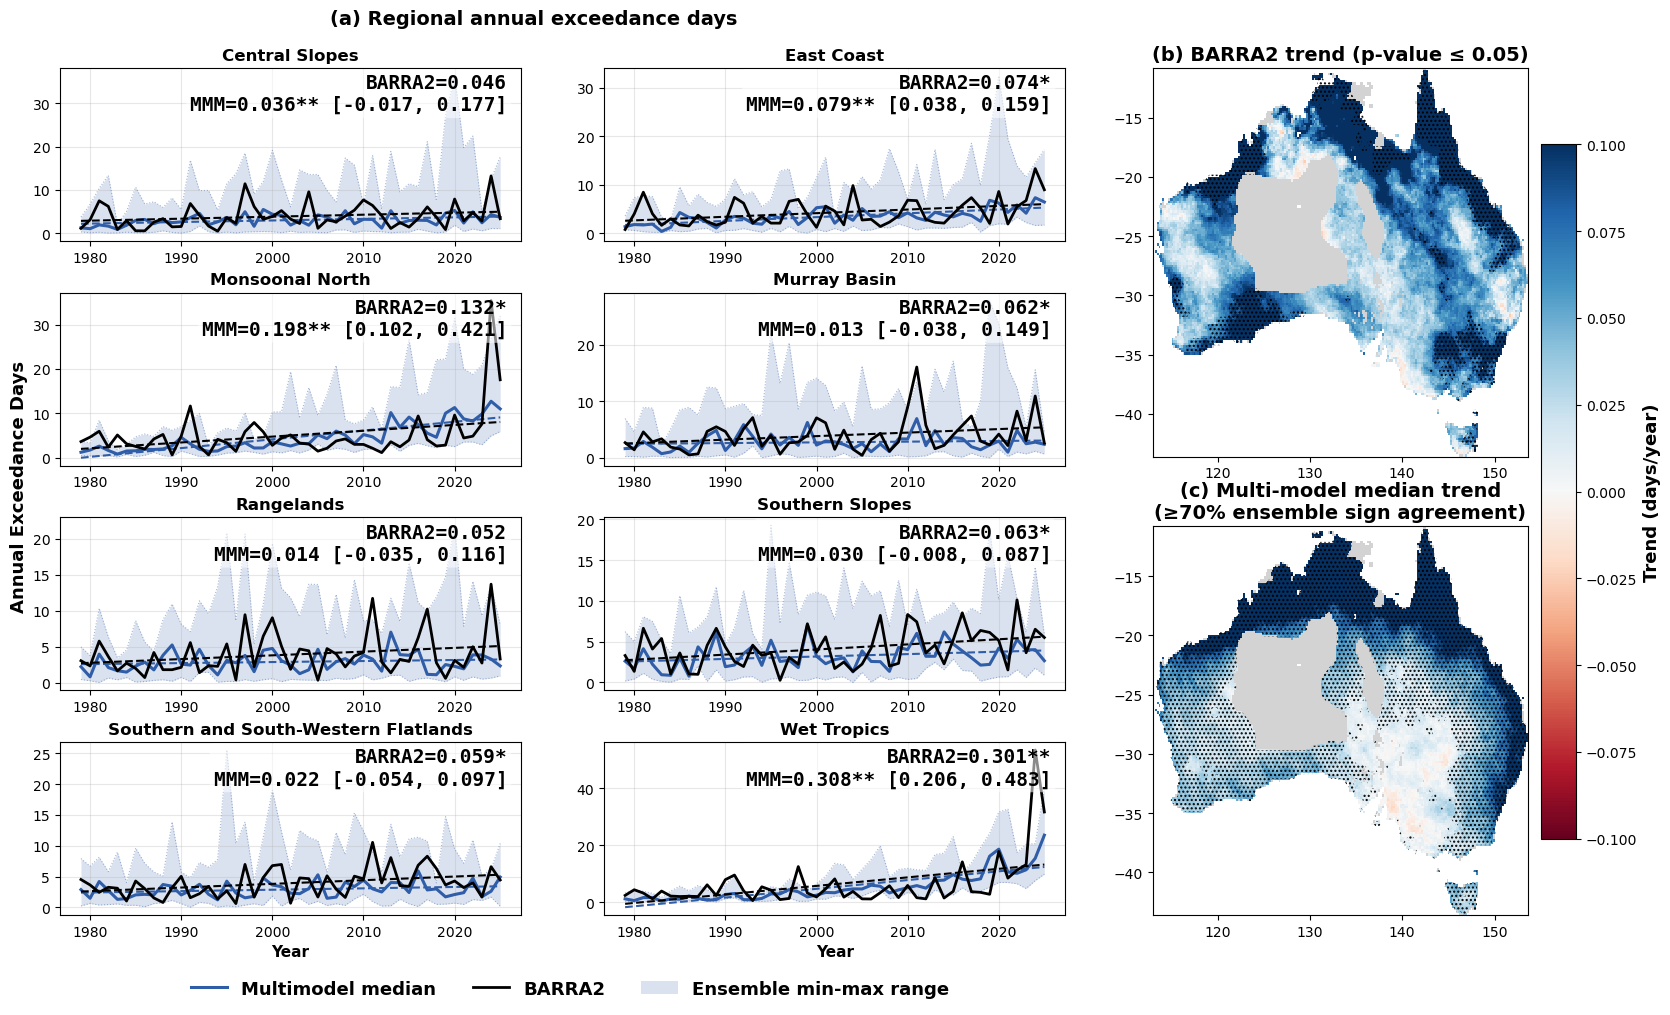

In [25]:

# ============================================================
# 8.5 COMBINED VISUALISATION -vp
# LEFT: NRM TIMESERIES (from redesign 5.2 style)
# RIGHT: BARRA2 + MMM TREND MAPS + exclude 
# 
# ============================================================

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.stats import linregress
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# SETTINGS
# ============================================================

summary_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/summaries"
)

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2"
)

output_dir.mkdir(exist_ok=True)

# ============================================================
# MODELS
# ============================================================

gcms = [
    "ACCESS-ESM1-5",
    "EC-Earth3-Veg",
    "MPI-ESM1-2-HR",
    "NorESM2-MM",
    "UKESM1-0-LL"
]

rcms = [
    "NARCliM2-0-WRF412R3",
    "NARCliM2-0-WRF412R5"
]

# ============================================================
# LOAD LAND MASK
# ============================================================

mask_file = (
    "/scratch/dt6/xw9650/tmp/regridded/"
    "sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_"
    "NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"
)

land_mask = xr.open_dataset(mask_file)["sftlf"] > 50

# ============================================================
# Excluded region MASK
# ============================================================
mask_region = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/original_awra_awap_mask.nc')

def regrid_mask(mask, target_data):
 
    mask = mask.sortby('lat')
 
    max_lat = mask['lat'].max().values
    min_lat = mask['lat'].min().values
    max_lon = mask['lon'].max().values
    min_lon = mask['lon'].min().values
 
    mask = mask.astype(int)
 
    target_data = target_data.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    regridded_mask = mask.interp_like(target_data, method='nearest')
    new_access_mask = regridded_mask.astype(bool)
 
    return new_access_mask


# ============================================================
# TREND FUNCTION
# ============================================================

def compute_trend(years, values):

    mask = np.isfinite(values)

    years = years[mask]
    values = values[mask]

    if len(years) < 3:
        return np.nan, np.nan

    res = linregress(years, values)

    return res.slope, res.pvalue


# ============================================================
# SIGNIFICANCE STARS
# ============================================================

def stars(p):

    if np.isnan(p):
        return ""

    if p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# LOAD BARRA2 SUMMARY
# ============================================================

barra2_file = summary_dir / "vp_BARRA2_summary_1979_2025.parquet"

barra2_df = pd.read_parquet(barra2_file)

# ============================================================
# LOAD MODEL SUMMARIES
# ============================================================

ensemble_data = {}

for gcm, rcm in product(gcms, rcms):

    file = (
        summary_dir /
        f"vp_{gcm}_{rcm}_summary_1979_2025.parquet"
    )

    if not file.exists():

        print(f"Missing:\n{file}")
        continue

    ensemble_data[f"{gcm}_{rcm}"] = (
        pd.read_parquet(file)
    )

# ============================================================
# DETECT NRMS
# ============================================================

nrms = sorted(barra2_df["NRM"].unique())

print("Detected NRMs:")
print(nrms)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(20, 11)
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[2.2, 1],
    height_ratios=[1, 1],
    wspace=0.12,
    hspace=0.18
)

# ============================================================
# LEFT PANEL SUBGRID
# ============================================================

left_gs = gs[:, 0].subgridspec(
    4,
    2,
    wspace=0.18,
    hspace=0.30
)

axes = []

for i in range(len(nrms)):

    row = i // 2
    col = i % 2

    axes.append(
        fig.add_subplot(left_gs[row, col])
    )

# ============================================================
# RIGHT MAP PANELS
# ============================================================

ax_barra2 = fig.add_subplot(gs[0, 1])
ax_mmm = fig.add_subplot(gs[1, 1])

# ============================================================
# STORAGE
# ============================================================

trend_rows = []

# ============================================================
# MAIN LOOP
# ============================================================

for i, (ax, nrm) in enumerate(zip(axes, nrms)):

    ensemble_dfs = []

    # ========================================================
    # COLLECT ENSEMBLE MEMBERS
    # ========================================================

    for member_name, df in ensemble_data.items():

        df_nrm = df[
            df["NRM"] == nrm
        ][[
            "year",
            "annual_exceedance_days"
        ]].copy()

        if df_nrm.empty:
            continue

        df_nrm.rename(
            columns={
                "annual_exceedance_days": member_name
            },
            inplace=True
        )

        ensemble_dfs.append(
            df_nrm.set_index("year")
        )

    if not ensemble_dfs:
        continue

    # ========================================================
    # CREATE ENSEMBLE
    # ========================================================

    df_ensemble = pd.concat(
        ensemble_dfs,
        axis=1
    )

    years = df_ensemble.index.values

    # ========================================================
    # ENSEMBLE STATISTICS
    # ========================================================

    ensemble_median = (
        df_ensemble.median(axis=1)
    )

    ensemble_min = (
        df_ensemble.min(axis=1)
    )

    ensemble_max = (
        df_ensemble.max(axis=1)
    )

    # ========================================================
    # ENSEMBLE MIN-MAX SPREAD
    # ========================================================

    ax.fill_between(
        years,
        ensemble_min,
        ensemble_max,
        color="#4C72B0",
        alpha=0.20,
        linewidth=0,
        zorder=1
    )

    # OPTIONAL:
    # show min/max boundaries more clearly

    ax.plot(
        years,
        ensemble_min,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    ax.plot(
        years,
        ensemble_max,
        color="#4C72B0",
        linewidth=0.8,
        alpha=0.5,
        linestyle=":"
    )

    # ========================================================
    # MULTIMODEL MEDIAN
    # ========================================================

    ax.plot(
        years,
        ensemble_median,
        color="#2F5DA8",
        linewidth=2.2,
        label="Multimodel median",
        zorder=3
    )

    # ========================================================
    # MODEL TRENDS
    # ========================================================

    ensemble_slopes = []

    for col in df_ensemble.columns:

        slope_i, p_i = compute_trend(
            years,
            df_ensemble[col].values
        )

        ensemble_slopes.append(slope_i)

        trend_rows.append({
            "NRM": nrm,
            "Source": col,
            "Slope": slope_i,
            "p_value": p_i
        })

    mod_slope, mod_p = compute_trend(
        years,
        ensemble_median.values
    )

    ens_min = np.nanmin(ensemble_slopes)
    ens_max = np.nanmax(ensemble_slopes)

    trend_rows.append({
        "NRM": nrm,
        "Source": "Multimodel median",
        "Slope": mod_slope,
        "p_value": mod_p
    })

    # ========================================================
    # MULTIMODEL TREND LINE
    # ========================================================

    if np.isfinite(mod_slope):

        fit_mod = (
            mod_slope * years
            + np.mean(
                ensemble_median
                - mod_slope * years
            )
        )

        ax.plot(
            years,
            fit_mod,
            color="#2F5DA8",
            linestyle="--",
            linewidth=1.5,
            zorder=4
        )

    # ========================================================
    # BARRA2
    # ========================================================

    df_barra2 = barra2_df[
        barra2_df["NRM"] == nrm
    ]

    barra2_slope = np.nan
    barra2_p = np.nan

    if not df_barra2.empty:

        ax.plot(
            df_barra2["year"],
            df_barra2["annual_exceedance_days"],
            color="black",
            linewidth=2,
            label="BARRA2",
            zorder=5
        )

        x_barra2 = df_barra2["year"].values

        y_barra2 = df_barra2[
            "annual_exceedance_days"
        ].values

        barra2_slope, barra2_p = compute_trend(
            x_barra2,
            y_barra2
        )

        trend_rows.append({
            "NRM": nrm,
            "Source": "BARRA2",
            "Slope": barra2_slope,
            "p_value": barra2_p
        })

        if np.isfinite(barra2_slope):

            fit_barra2 = (
                barra2_slope * x_barra2
                + np.mean(
                    y_barra2
                    - barra2_slope * x_barra2
                )
            )

            ax.plot(
                x_barra2,
                fit_barra2,
                color="black",
                linestyle="--",
                linewidth=1.5,
                zorder=6
            )

    # ========================================================
    # PANEL TEXT
    # ========================================================

    text_str = (
        f"BARRA2={barra2_slope:.3f}{stars(barra2_p)}\n"
        f"MMM={mod_slope:.3f}{stars(mod_p)} "
        f"[{ens_min:.3f}, {ens_max:.3f}]"
    )

    # ax.text(
    #     0.97,
    #     0.97,
    #     text_str,
    #     transform=ax.transAxes,
    #     ha="right",
    #     va="top",
    #     fontsize=7.8,
    #     bbox=dict(
    #         facecolor="white",
    #         alpha=0.75,
    #         edgecolor="none",
    #         pad=1.5
    #     ),
    #     zorder=10
    # )
    ax.text(
        0.97,
        0.97,
        text_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight='bold',
        family="monospace",
        linespacing=1.2,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            alpha=0.55,
            edgecolor="none"
        ),
        zorder=10
    )
    # ========================================================
    # PANEL STYLE
    # ========================================================

    ax.set_title(
        nrm,
        fontsize=12,
        fontweight="bold"
    )

    row = i // 2

    if row == 3:

        ax.set_xlabel(
            "Year",
            fontsize=11,
            fontweight="bold"
        )

    else:

        ax.set_xlabel("")

    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(
        FormatStrFormatter("%d")
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    ax.grid(
        alpha=0.3
    )

# ============================================================
# GLOBAL Y LABEL
# ============================================================

fig.text(
    0.1,
    0.5,
    "Annual Exceedance Days",
    va="center",
    rotation="vertical",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# LOAD TREND MAPS
# ============================================================

barra2_ds = xr.open_dataset(
    trend_dir / "vp_BARRA2_trend_1979_2025.nc"
)

mmm_ds = xr.open_dataset(
    trend_dir / "vp_MMM_trend_1979_2025.nc"
)

# ============================================================
# ALIGN MASK
# ============================================================

barra2_ds, land_mask_aligned = xr.align(
    barra2_ds,
    land_mask,
    join="inner"
)

mmm_ds, land_mask_aligned = xr.align(
    mmm_ds,
    land_mask,
    join="inner"
)

barra2_land = barra2_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
barra2_land_mask = regrid_mask(mask_region, barra2_land)
barra2_land_masked = barra2_land.where(barra2_land_mask)
    


mmm_land = mmm_ds.where(
    land_mask_aligned
)
#overlay with regions removing limited stations 
mmm_land_mask = regrid_mask(mask_region, mmm_land)
mmm_land_masked = mmm_land.where(mmm_land_mask)
    
# ============================================================
# PLOT MAPS
# ============================================================

vmin = -0.1
vmax = 0.1

# ============================================================
# CREATE EXCLUDED LAND MASK
# ============================================================

# valid region mask after regridding
# True  = keep
# False = excluded

excluded_barra2 = (
    land_mask_aligned &
    (~barra2_land_mask)
)

excluded_mmm = (
    land_mask_aligned &
    (~mmm_land_mask)
)

# ============================================================
# LIGHT GRAY COLORMAP
# ============================================================

from matplotlib.colors import ListedColormap

gray_cmap = ListedColormap(["lightgray"])

# ============================================================
# PLOT EXCLUDED LAND FIRST
# ============================================================

xr.where(
    excluded_barra2,
    1,
    np.nan
).plot(
    ax=ax_barra2,
    cmap=gray_cmap,
    add_colorbar=False
)

xr.where(
    excluded_mmm,
    1,
    np.nan
).plot(
    ax=ax_mmm,
    cmap=gray_cmap,
    add_colorbar=False
)

# ============================================================
# OVERLAY ACTUAL TREND DATA
# ============================================================

barra2_plot = barra2_land_masked.trend.plot(
    ax=ax_barra2,
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

# ============================================================
# BARRA2 SIGNIFICANCE STIPPLING (p <= 0.05)
# ============================================================

if "p_value" in barra2_land_masked:

    sig = barra2_land_masked["p_value"] <= 0.05

    step = 3  # adjust density (2–5 usually works well)

    sig_sparse = sig[::step, ::step]

    ax_barra2.contourf(
        barra2_land_masked.lon[::step],
        barra2_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
        # transform=barra2_plot.axes.get_transform("data")  # optional safety
    )
    

mmm_plot = mmm_land_masked.MMM_trend.plot(
    ax=ax_mmm,
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
# ============================================================
# REMOVE AXIS LABELS (RIGHT PANELS)
# ============================================================

for ax in [ax_barra2, ax_mmm]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.tick_params(
    #     axis="both",
    #     which="both",
    #     length=3,      # removes tick marks
    #     labelbottom=False,
    #     labelleft=False
    # )
# # ============================================================
# # SIGN AGREEMENT STIPPLING
# # ============================================================

# if "sign_agreement" in mmm_land:

#     sig = mmm_land["sign_agreement"] >= 0.7

#     yy, xx = np.where(sig.values)

#     # reduced density for visibility

#     step = 10

#     yy = yy[::step]
#     xx = xx[::step]

#     ax_mmm.scatter(
#         mmm_land.lon.values[xx],
#         mmm_land.lat.values[yy],
#         s=0.7,
#         color="black",
#         alpha=0.28
#     )


# ============================================================
# HATCHING (70% AGREEMENT)
# ============================================================

if "sign_agreement" in mmm_land_masked:

    sig = mmm_land_masked["sign_agreement"] >= 0.7

    step = 2  # try 2, 3, 4, 5 depending on resolution

    sig_sparse = sig[::step, ::step]

    ax_mmm.contourf(
        mmm_land_masked.lon[::step],
        mmm_land_masked.lat[::step],
        sig_sparse.astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
    )
    
# ============================================================
# MAP TITLES
# ============================================================

ax_barra2.set_title(
    "(b) BARRA2 trend (p-value ≤ 0.05)",
    fontsize=14,
    fontweight="bold"
)

ax_mmm.set_title(
    "(c) Multi-model median trend\n"
    "(≥70% ensemble sign agreement)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    barra2_plot,
    ax=[ax_barra2, ax_mmm],
    shrink=0.82,
    pad=0.03
)

cbar.set_label(
    "Trend (days/year)",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# PANEL LABEL
# ============================================================

fig.text(
    0.26,
    0.92,
    "(a) Regional annual exceedance days",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# FIGURE LEGEND
# ============================================================

legend_handles = [

    plt.Line2D(
        [0], [0],
        color="#2F5DA8",
        linewidth=2.2
    ),

    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=2
    ),

    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor="#4C72B0",
        alpha=0.20
    )
]

# fig.legend(
#     legend_handles,
#     [
#         "Multimodel median",
#         "BARRA2",
#         "Ensemble min-max range"
#     ],
#     loc="lower center",
#     ncol=3,
#     fontsize=11,
#     frameon=False
# )
# ============================================================
# FIGURE LEGEND (LEFT PANEL ONLY)--CHANGE1
# ============================================================

# Get bounding box of left panel group
left_bbox = gs[:, 0].get_position(fig)

legend_handles = [

    plt.Line2D([0], [0], color="#2F5DA8", linewidth=2.2),
    plt.Line2D([0], [0], color="black", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, facecolor="#4C72B0", alpha=0.20)

]

legend=fig.legend(
    legend_handles,
    [
        "Multimodel median",
        "BARRA2",
        "Ensemble min-max range"
    ],
    loc="lower center",
    # bbox_to_anchor=(
    #     (left_bbox.x0 + left_bbox.x1) / 2,  # center x of LEFT panel
    #     left_bbox.y0 - 0.02                 # slightly below left panel
    # ),
    bbox_to_anchor=(0.38, 0.02),  # 👈 move into left panel bottom
    ncol=3,
    fontsize=13, #increase font size (CHANGE3),
    frameon=False
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# ============================================================
# SAVE TREND TABLE
# ============================================================

trend_df = pd.DataFrame(trend_rows)

trend_df["Slope"] = (
    trend_df["Slope"]
    .astype(float)
    .round(4)
)

trend_df["p_value"] = (
    trend_df["p_value"]
    .astype(float)
    .round(4)
)

trend_df["Slope_sig"] = (
    trend_df["Slope"].astype(str)
    + trend_df["p_value"].apply(stars)
)

trend_csv = (
    output_dir /
    "vp_annual_exceedance_trends_1979_2025.csv"
)

trend_xlsx = (
    output_dir /
    "vp_annual_exceedance_trends_1979_2025.xlsx"
)

trend_df.to_csv(
    trend_csv,
    index=False
)

trend_df.to_excel(
    trend_xlsx,
    index=False
)

print(f"Saved trend table:\n{trend_csv}")

# ============================================================
# SAVE FIGURE
# ============================================================

plt.tight_layout(
    rect=[0.05, 0.04, 1, 0.95]
)

fig_file = (
    output_dir /
    "vp_combined_timeseries_maps_1979_2025.png"
)

fig.savefig(
    fig_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure:\n{fig_file}")

plt.show()